## CUDA

In [2]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 115.9 MB/s eta 0:00:22
     ---------------------------------------- 0.0/2.4 GB 108.7 MB/s eta 0:00:23
     ---------------------------------------- 0.0/2.4 GB 108.8 MB/s eta 0:00:23
     ---------------------------------------- 0.0/2.4 GB 108.8 MB/s eta 0:00:23
     ---------------------------------------- 0.0/2.4 GB 93.9 MB/s eta 0:00:26
     ---------------------------------------- 0.0/2.4 GB 81.8 MB/s eta 0:00:30
     ---------------------------------------- 0.0/2.4 GB 81.8 MB/s eta 0:00:30
      --------------------------------------- 0.0/2.4 GB 81.8 MB/s eta 0:00:30
      --------------------------------------- 0.0/2.4 GB 108.8 MB/s eta 0:00:23
      --------------------------------------- 0.0/2.4 GB 108.8 MB/s eta 0:00:23
      --------------------------------------- 0.1/2.4 GB 110.0 MB/s eta 0:

## Only CPU

In [3]:
!pip install torch torchvision

In [4]:
!pip install optuna

  Obtaining dependency information for optuna from https://files.pythonhosted.org/packages/ab/f3/e5fcd5d9b15771ed6dc10e3a7eeddc672e418f4f4c4653d216cc1d857e2d/optuna-4.9.0-py3-none-any.whl.metadata
  Obtaining dependency information for alembic>=1.5.0 from https://files.pythonhosted.org/packages/20/89/e62cc37b69ad357cc8ecd6e7367f5245f523d3cbb338a66197212bdf6749/alembic-1.19.1-py3-none-any.whl.metadata
  Obtaining dependency information for colorlog from https://files.pythonhosted.org/packages/d4/19/0b6647bf5e331521e55d2b63bfbdc210bd9cd605189273f03614a05f702d/colorlog-6.12.0-py3-none-any.whl.metadata
  Obtaining dependency information for Mako from https://files.pythonhosted.org/packages/a5/54/12ed58d458474aaab5c3d180173e745a4fe131bb330370596876d19ff60f/mako-1.4.1-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/425.6 kB ? eta -:--:--
   -- ------------------------------------ 30.7/425.6 kB 660.6 kB/s eta 0:00:01
   --- ----------------------------------- 41.0/42

In [5]:
import torch
import torchvision

print("✅ PyTorch version:", torch.__version__)
print("✅ Torchvision version:", torchvision.__version__)
print("✅ CUDA acceleration available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("🛸 Active GPU Device:", torch.cuda.get_device_name(0))

✅ PyTorch version: 2.5.1+cu121
✅ Torchvision version: 0.20.1+cu121
✅ CUDA acceleration available: True
🛸 Active GPU Device: NVIDIA GeForce RTX 2080 SUPER


In [2]:
import os

DATASET_PATH = "dataset/PCB_DATASET"

# --- 1. File System Overview ---
print(f"\n[SECTION 1] Directory Inspection: {DATASET_PATH}")
print("-" * 40)
count = 0
for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        # if count < 10:  # Show first 10 files as examples
        #     print(f"Found: {os.path.join(root, file)}")
        #     count += 1
        print(f"Found: {os.path.join(root, file)}")
if count == 0:
    print("Warning: No files found. Please check your path.")


[SECTION 1] Directory Inspection: dataset/PCB_DATASET
----------------------------------------
Found: dataset/PCB_DATASET\rotate.py
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_01.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_02.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_03.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_04.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_05.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_06.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_07.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_08.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_09.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_10.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_11.xml
Found: dataset/PCB_DATASET\Annotations\Mis

## Import & Parameter

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

# Ensure scikit-image is available for SSIM-NET simulation
try:
    from skimage.metrics import structural_similarity as ssim
except ImportError:
    # Fallback message to assist in setting up the environment
    raise ImportError("Please install scikit-image using: pip install scikit-image")

# Set up global parameters for comparison algorithm input requirements
TARGET_SIZE = (224, 224) # Standard input size for LPViT, ResNet, MobileNet, and AlexNet
PIXELS_PER_MM = 15.0     # Default spatial calibration factor

print("✅ Initialization complete. Target patch dimension set to:", TARGET_SIZE)

✅ Initialization complete. Target patch dimension set to: (224, 224)


## Data Augmentation Module

In [20]:
# ==============================================================================
# DATA AUGMENTATION MODULE (WITH AUTOMATED SYSTEM LOGGING, MULTI-SCALE PREVIEW)
# ==============================================================================
import os
import random
import shutil
import cv2
import datetime
import numpy as np
import xml.etree.ElementTree as ET
from pathlib import Path
from IPython.display import display, Image
from tqdm.notebook import tqdm

# --- 0. Self-Contained Seeding & Logging Helpers ---
LOG_FILE_PATH = "experiment_results_log.txt"
VISUAL_LOG_DIR = "log"  # Folder where visual verification images are saved

def set_seed(seed=42):
    """Sets deterministic seeds across Python and NumPy libraries for cross-machine consistency."""
    random.seed(seed)
    np.random.seed(seed)
    cv2.setRNGSeed(seed)  # <--- Essential for reproducible RANSAC homography

def log_message(message):
    """Prints to console and appends to the unified local log file on disk with timestamps."""
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    formatted_msg = f"[{timestamp}] {message}"
    print(message)
    with open(LOG_FILE_PATH, "a", encoding="utf-8") as f:
        f.write(formatted_msg + "\n")

# --- RESIZING ASPECT-RATIO HELPER ---
def calculate_resized_dimensions(h, w, max_dim):
    """Calculates new dimensions keeping the original aspect ratio."""
    scale = max_dim / max(h, w)
    return (int(w * scale), int(h * scale)), scale

# --- HIGH-RES BOX DRAWERS ---
def draw_visual_log_boxes(img, xml_path_obj, thickness=4, font_scale=0.6):
    """Draws boxes and labels on original high-res canvas (used for GLOBAL_LOG saving)."""
    canvas = img.copy()
    if xml_path_obj and xml_path_obj.exists():
        root = ET.parse(str(xml_path_obj)).getroot()
        for obj in root.findall('object'):
            bndbox = obj.find('bndbox')
            if bndbox is not None:
                xmin = int(float(bndbox.find('xmin').text))
                ymin = int(float(bndbox.find('ymin').text))
                xmax = int(float(bndbox.find('xmax').text))
                ymax = int(float(bndbox.find('ymax').text))
                
                name = obj.find('name').text
                color = (0, 0, 255) if name.lower() in ["missing_hole", "mouse_bite"] else (0, 255, 0)
                
                cv2.rectangle(canvas, (xmin, ymin), (xmax, ymax), color, thickness)
                cv2.putText(canvas, name, (xmin, ymin - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, font_scale, color, 2, cv2.LINE_AA)
    return canvas

def draw_boxes_on_resized(resized_img, xml_path_obj, scale_x, scale_y, thickness=2, font_scale=0.35):
    """Draws precise crisp bounding boxes directly on downscaled preview canvases."""
    canvas = resized_img.copy()
    if xml_path_obj and xml_path_obj.exists():
        root = ET.parse(str(xml_path_obj)).getroot()
        for obj in root.findall('object'):
            bndbox = obj.find('bndbox')
            if bndbox is not None:
                xmin = int(float(bndbox.find('xmin').text))
                ymin = int(float(bndbox.find('ymin').text))
                xmax = int(float(bndbox.find('xmax').text))
                ymax = int(float(bndbox.find('ymax').text))
                
                s_xmin = int(xmin * scale_x)
                s_ymin = int(ymin * scale_y)
                s_xmax = int(xmax * scale_x)
                s_ymax = int(ymax * scale_y)
                
                name = obj.find('name').text
                color = (0, 0, 255) if name.lower() in ["missing_hole", "mouse_bite"] else (0, 255, 0)
                
                cv2.rectangle(canvas, (s_xmin, s_ymin), (s_xmax, s_ymax), color, thickness)
                cv2.putText(canvas, name, (s_xmin, s_ymin - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, font_scale, color, 1, cv2.LINE_AA)
    return canvas

def save_zoomed_visual_logs(img, xml_path_obj, save_dir_obj, base_filename, padding=120):
    """Crops a highly focused close-up around each defect and saves to disk."""
    if not (xml_path_obj and xml_path_obj.exists()):
        return 0
    root = ET.parse(str(xml_path_obj)).getroot()
    h_img, w_img = img.shape[:2]
    saved_count = 0
    for idx, obj in enumerate(root.findall('object')):
        name = obj.find('name').text
        bndbox = obj.find('bndbox')
        if bndbox is not None:
            xmin = int(float(bndbox.find('xmin').text))
            ymin = int(float(bndbox.find('ymin').text))
            xmax = int(float(bndbox.find('xmax').text))
            ymax = int(float(bndbox.find('ymax').text))
            c_xmin, c_ymin = max(0, xmin - padding), max(0, ymin - padding)
            c_xmax, c_ymax = min(w_img, xmax + padding), min(h_img, ymax + padding)
            
            zoomed_crop = img[c_ymin:c_ymax, c_xmin:c_xmax].copy()
            r_xmin, r_ymin = xmin - c_xmin, ymin - c_ymin
            r_xmax, r_ymax = xmax - c_xmin, ymax - c_ymin
            
            color = (0, 0, 255) if name.lower() in ["missing_hole", "mouse_bite"] else (0, 255, 0)
            cv2.rectangle(zoomed_crop, (r_xmin, r_ymin), (r_xmax, r_ymax), color, 3)
            text_y = r_ymin - 10 if r_ymin - 10 > 15 else r_ymin + 20
            cv2.putText(zoomed_crop, name, (r_xmin, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2, cv2.LINE_AA)
            
            log_img_name = f"ZOOM_LOG_{base_filename}_defect_{idx}{Path(xml_path_obj).stem}.jpg"
            cv2.imwrite(str(save_dir_obj / log_img_name), zoomed_crop)
            log_message(f"📝 [ZOOMED-IN LOG SAVED] -> {save_dir_obj / log_img_name}")
            saved_count += 1
    return saved_count

# --- 1. Image-Level Transformations (Applied to ALL classes) ---

def adjust_brightness(image, beta):
    """Adjusts image brightness globally."""
    return cv2.convertScaleAbs(image, alpha=1.0, beta=beta)

def adjust_exposure(image, gamma):
    """Applies non-linear Gamma Correction to simulate camera exposure changes."""
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(image, table)

def add_gaussian_noise(image, mean=0, sigma=20):
    """Adds high-frequency Gaussian noise globally to simulate camera sensor noise."""
    gauss = np.random.normal(mean, sigma, image.shape).astype('float32')
    noisy_image = np.clip(image.astype('float32') + gauss, 0, 255)
    return noisy_image.astype('uint8')

# --- 2. Bounding-Box Level Transformations (Targeted classes only) ---

def rotate_bbox_only(image, xml_path, angle, target_classes=['Mouse_bite', 'Missing_hole']):
    """Crops the defect ROI, rotates it, and pastes it back inside coordinates."""
    if not (xml_path and Path(xml_path).exists()):
        return image
    xml_tree = ET.parse(str(xml_path))
    root = xml_tree.getroot()
    rotated_image = image.copy()
    h_img, w_img = image.shape[:2]
    target_classes_lower = [c.lower() for c in target_classes]
    
    for obj in root.findall('object'):
        class_name = obj.find('name').text
        if class_name.lower() in target_classes_lower:
            bndbox = obj.find('bndbox')
            if bndbox is not None:
                xmin, ymin = int(float(bndbox.find('xmin').text)), int(float(bndbox.find('ymin').text))
                xmax, ymax = int(float(bndbox.find('xmax').text)), int(float(bndbox.find('ymax').text))
                xmin, ymin = max(0, xmin), max(0, ymin)
                xmax, ymax = min(w_img, xmax), min(h_img, ymax)
                w_box, h_box = xmax - xmin, ymax - ymin
                if w_box <= 0 or h_box <= 0:
                    continue
                
                roi = image[ymin:ymax, xmin:xmax]
                center = (w_box / 2.0, h_box / 2.0)
                M = cv2.getRotationMatrix2D(center, angle, 1.0)
                rotated_roi = cv2.warpAffine(roi, M, (w_box, h_box), borderMode=cv2.BORDER_REFLECT)
                rotated_image[ymin:ymax, xmin:xmax] = rotated_roi
    return rotated_image

# --- 3. Workspace Management & Preview ---

def reset_augmented_data(*folder_paths):
    """Recursively deletes specified folders to reset workspace with logging."""
    deleted = False
    for folder in folder_paths:
        path_obj = Path(folder)
        if path_obj.exists():
            shutil.rmtree(path_obj)
            log_message(f"🗑️ Removed directory tree: {path_obj}")
            deleted = True
    if not deleted:
        log_message("⚠️ Specified directories do not exist. Nothing cleared.")

def preview_augmentation(
    image_dir, 
    annotation_dir,
    beta_range=(25, 45), 
    gamma_range=(1.3, 1.7),
    sigma_range=(15, 30),
    angle_range=(-15, 15),
    bbox_rotation_prob=0.5,
    preview_zoom_padding=120,
    seed=42  # Seed added for reproducible preview generation
):
    """
    Renders a 10-image visualization layout showing Original, Bright, Exposed, Noise, and BBox Rotated.
    Saves all 10 pictures individually as high-resolution files reproducibly across runs.
    """
    if seed is not None:
        set_seed(seed)

    img_path_obj, ann_path_obj = Path(image_dir), Path(annotation_dir)
    if not img_path_obj.exists() and Path(f"dataset/{image_dir}").exists():
        img_path_obj = Path(f"dataset/{image_dir}")
    if not ann_path_obj.exists() and Path(f"dataset/{annotation_dir}").exists():
        ann_path_obj = Path(f"dataset/{annotation_dir}")
        
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp')
    # Explicitly sorted to avoid cross-OS non-deterministic filesystem order
    image_paths = sorted([p for p in img_path_obj.rglob('*') if p.suffix.lower() in valid_exts])
    if not image_paths:
        log_message(f"⚠️ No images found in: {image_dir}")
        return
    
    target_sample_paths = [p for p in image_paths if p.parent.name.lower() in ['mouse_bite', 'missing_hole']]
    sample_path = random.choice(target_sample_paths) if target_sample_paths else random.choice(image_paths)
    
    relative_subpath = sample_path.relative_to(img_path_obj)
    xml_path = ann_path_obj / relative_subpath.parent / f"{sample_path.stem}.xml"

    img_bgr = cv2.imread(str(sample_path))
    if img_bgr is None:
        return
        
    h, w = img_bgr.shape[:2]

    # Find first defect for close-up cropping
    c_xmin, c_ymin, c_xmax, c_ymax = 0, 0, w, h
    xmin, ymin, xmax, ymax = 0, 0, w, h
    has_defect = False
    
    if xml_path.exists():
        root = ET.parse(str(xml_path)).getroot()
        for obj in root.findall('object'):
            bndbox = obj.find('bndbox')
            if bndbox is not None:
                xmin, ymin = int(float(bndbox.find('xmin').text)) , int(float(bndbox.find('ymin').text))
                xmax, ymax = int(float(bndbox.find('xmax').text)) , int(float(bndbox.find('ymax').text))
                c_xmin, c_ymin = max(0, xmin - preview_zoom_padding), max(0, ymin - preview_zoom_padding)
                c_xmax, c_ymax = min(w, xmax + preview_zoom_padding), min(h, ymax + preview_zoom_padding)
                has_defect = True
                break

    mid_beta = sum(beta_range) // 2
    mid_gamma = sum(gamma_range) / 2.0
    mid_sigma = sum(sigma_range) // 2
    mid_angle = sum(angle_range) / 2.0 or 12.0

    # Apply operations to full-size canvas
    aug_bright = adjust_brightness(img_bgr, beta=mid_beta)
    aug_exposed = adjust_exposure(img_bgr, gamma=mid_gamma)
    aug_noisy = add_gaussian_noise(img_bgr, sigma=mid_sigma)
    aug_combined = rotate_bbox_only(aug_bright, xml_path, angle=mid_angle)

    # 1. GENERATE THE 5 HIGH-QUALITY GLOBAL PICTURES
    dim_global, scale_global = calculate_resized_dimensions(h, w, max_dim=500)
    g_orig = draw_boxes_on_resized(cv2.resize(img_bgr, dim_global), xml_path, scale_global, scale_global, thickness=1, font_scale=0.28)
    g_bright = draw_boxes_on_resized(cv2.resize(aug_bright, dim_global), xml_path, scale_global, scale_global, thickness=1, font_scale=0.28)
    g_exposed = draw_boxes_on_resized(cv2.resize(aug_exposed, dim_global), xml_path, scale_global, scale_global, thickness=1, font_scale=0.28)
    g_noisy = draw_boxes_on_resized(cv2.resize(aug_noisy, dim_global), xml_path, scale_global, scale_global, thickness=1, font_scale=0.28)
    g_comb = draw_boxes_on_resized(cv2.resize(aug_combined, dim_global), xml_path, scale_global, scale_global, thickness=1, font_scale=0.28)

    # 2. GENERATE THE 5 HIGH-QUALITY CLOSE-UP ZOOMED PICTURES
    crop_orig = img_bgr[c_ymin:c_ymax, c_xmin:c_xmax].copy()
    crop_bright = aug_bright[c_ymin:c_ymax, c_xmin:c_xmax].copy()
    crop_exposed = aug_exposed[c_ymin:c_ymax, c_xmin:c_xmax].copy()
    crop_noisy = aug_noisy[c_ymin:c_ymax, c_xmin:c_xmax].copy()
    crop_combined = aug_combined[c_ymin:c_ymax, c_xmin:c_xmax].copy()

    r_h, r_w = crop_orig.shape[:2]
    dim_zoom, scale_zoom = calculate_resized_dimensions(r_h, r_w, max_dim=400)
    
    def draw_relative_boxes(canvas, label_name, color):
        if has_defect:
            r_xmin = int((xmin - c_xmin) * scale_zoom)
            r_ymin = int((ymin - c_ymin) * scale_zoom)
            r_xmax = int((xmax - c_xmin) * scale_zoom)
            r_ymax = int((ymax - c_ymin) * scale_zoom)
            cv2.rectangle(canvas, (r_xmin, r_ymin), (r_xmax, r_ymax), color, 3)
            cv2.putText(canvas, label_name, (r_xmin, r_ymin - 5), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)
        return canvas

    z_orig = draw_relative_boxes(cv2.resize(crop_orig, dim_zoom), "Original", (0, 255, 0))
    z_bright = draw_relative_boxes(cv2.resize(crop_bright, dim_zoom), "Bright", (0, 255, 0))
    z_exposed = draw_relative_boxes(cv2.resize(crop_exposed, dim_zoom), "Exposed", (0, 255, 0))
    z_noisy = draw_relative_boxes(cv2.resize(crop_noisy, dim_zoom), "Noisy", (0, 255, 0))
    z_comb = draw_relative_boxes(cv2.resize(crop_combined, dim_zoom), "Rotated", (0, 0, 255))

    # --- 3. PHYSICALLY SAVE ALL 10 PICTURES INDIVIDUALLY IN HIGH RESOLUTION ---
    log_dir_obj = Path(VISUAL_LOG_DIR)
    log_dir_obj.mkdir(parents=True, exist_ok=True)
    
    s_dim_global, s_scale_global = calculate_resized_dimensions(h, w, max_dim=800)
    cv2.imwrite(str(log_dir_obj / "PREVIEW_1_Global_Original.jpg"), draw_boxes_on_resized(cv2.resize(img_bgr, s_dim_global), xml_path, s_scale_global, s_scale_global, thickness=3, font_scale=0.5))
    cv2.imwrite(str(log_dir_obj / "PREVIEW_2_Global_Bright.jpg"), draw_boxes_on_resized(cv2.resize(aug_bright, s_dim_global), xml_path, s_scale_global, s_scale_global, thickness=3, font_scale=0.5))
    cv2.imwrite(str(log_dir_obj / "PREVIEW_3_Global_Exposed.jpg"), draw_boxes_on_resized(cv2.resize(aug_exposed, s_dim_global), xml_path, s_scale_global, s_scale_global, thickness=3, font_scale=0.5))
    cv2.imwrite(str(log_dir_obj / "PREVIEW_4_Global_Noise.jpg"), draw_boxes_on_resized(cv2.resize(aug_noisy, s_dim_global), xml_path, s_scale_global, s_scale_global, thickness=3, font_scale=0.5))
    cv2.imwrite(str(log_dir_obj / "PREVIEW_5_Global_BBox_Rotated.jpg"), draw_boxes_on_resized(cv2.resize(aug_combined, s_dim_global), xml_path, s_scale_global, s_scale_global, thickness=3, font_scale=0.5))
    
    s_dim_zoom, s_scale_zoom = calculate_resized_dimensions(r_h, r_w, max_dim=600)
    def draw_relative_boxes_high_res(canvas, label_name, color):
        if has_defect:
            r_xmin = int((xmin - c_xmin) * s_scale_zoom)
            r_ymin = int((ymin - c_ymin) * s_scale_zoom)
            r_xmax = int((xmax - c_xmin) * s_scale_zoom)
            r_ymax = int((ymax - c_ymin) * s_scale_zoom)
            cv2.rectangle(canvas, (r_xmin, r_ymin), (r_xmax, r_ymax), color, 4)
            cv2.putText(canvas, label_name, (r_xmin, r_ymin - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA)
        return canvas
        
    cv2.imwrite(str(log_dir_obj / "PREVIEW_6_Zoom_Original.jpg"), draw_relative_boxes_high_res(cv2.resize(crop_orig, s_dim_zoom), "Original", (0, 255, 0)))
    cv2.imwrite(str(log_dir_obj / "PREVIEW_7_Zoom_Bright.jpg"), draw_relative_boxes_high_res(cv2.resize(crop_bright, s_dim_zoom), "Bright", (0, 255, 0)))
    cv2.imwrite(str(log_dir_obj / "PREVIEW_8_Zoom_Exposed.jpg"), draw_relative_boxes_high_res(cv2.resize(crop_exposed, s_dim_zoom), "Exposed", (0, 255, 0)))
    cv2.imwrite(str(log_dir_obj / "PREVIEW_9_Zoom_Noise.jpg"), draw_relative_boxes_high_res(cv2.resize(crop_noisy, s_dim_zoom), "Noisy", (0, 255, 0)))
    cv2.imwrite(str(log_dir_obj / "PREVIEW_10_Zoom_BBox_Rotated.jpg"), draw_relative_boxes_high_res(cv2.resize(crop_combined, s_dim_zoom), "Rotated", (0, 0, 255)))

    log_message(f"📁 High-resolution visual logs successfully written! 10 individual preview files saved to: {log_dir_obj}/")

    # --- 4. DISPLAY ALL 10 PICTURES IN JUPYTER INLINE ---
    grid_global = np.hstack([g_orig, g_bright, g_exposed, g_noisy, g_comb])
    labels_g = ["Original (Full)", f"Bright (+{mid_beta})", f"Exposed (g={mid_gamma:.2f})", f"Noise (s={mid_sigma})", f"BBox Rot ({mid_angle:.1f}deg)"]
    w_step_g = dim_global[0]
    for i, text in enumerate(labels_g):
        cv2.putText(grid_global, text, (5 + (i * w_step_g), 20), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)
        
    grid_zoom = np.hstack([z_orig, z_bright, z_exposed, z_noisy, z_comb])
    labels_z = ["Original (Zoom)", "Bright (Zoom)", "Exposed (Zoom)", "Noise (Zoom)", "BBox Rot (Zoom)"]
    w_step_z = dim_zoom[0]
    for i, text in enumerate(labels_z):
        cv2.putText(grid_zoom, text, (5 + (i * w_step_z), 20), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

    log_message(f"ℹ️ Seed initialized to: {seed}")
    log_message(f"ℹ️ Configured BBox rotation chance per target sample: {bbox_rotation_prob * 100:.0f}%")
    
    # Render Global views grid
    log_message("\n📺 RENDER ROW 1: Global PCB Board Comparison")
    _, buffer_g = cv2.imencode('.jpg', grid_global)
    display(Image(data=buffer_g.tobytes()))
    
    # Render Zoomed close-up views grid
    log_message("📺 RENDER ROW 2: Magnified Local Defect Close-Ups")
    _, buffer_z = cv2.imencode('.jpg', grid_zoom)
    display(Image(data=buffer_z.tobytes()))

# --- 4. Batch Dataset Augmentation ---

def augment_dataset(
    image_dir, 
    annotation_dir, 
    output_img_dir, 
    output_xml_dir, 
    sample_ratio=0.3,
    beta_range=(25, 45),
    gamma_range=(1.3, 1.7),
    sigma_range=(15, 30),
    angle_range=(-15, 15),
    bbox_rotation_prob=0.5,
    max_visual_logs=15,  # Limit of how many annotated close-ups to save
    zoom_padding=120,    # Padding in pixels around the defect for zoomed visual logging
    seed=42              # Fixed random seed parameter for cross-machine consistency
):
    """
    Applies image-level transformations (brightness/noise/exposure) to all classes, 
    and applies localized bounding box rotations conditionally to targeted classes.
    Uses fixed random seeding to guarantee consistent augmentation across systems.
    """
    if seed is not None:
        set_seed(seed)

    img_path_obj = Path(image_dir)
    ann_path_obj = Path(annotation_dir)
    out_img_obj = Path(output_img_dir)
    out_xml_obj = Path(output_xml_dir)
    log_dir_obj = Path(VISUAL_LOG_DIR)

    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    # Explicitly sorted to guarantee identical image order across Linux/macOS/Windows OS traversals
    image_paths = sorted([p for p in img_path_obj.rglob('*') if p.suffix.lower() in valid_extensions])

    if not image_paths:
        log_message(f"⚠️ No images found in: {image_dir}")
        return

    num_to_augment = int(len(image_paths) * sample_ratio)
    selected_images = random.sample(image_paths, num_to_augment)
    
    # Reset/Create the 'log/' visual verification folder
    if log_dir_obj.exists():
        shutil.rmtree(log_dir_obj)
    log_dir_obj.mkdir(parents=True, exist_ok=True)
    
    # Determine indices of which samples will be saved as close-up visual logs
    visual_log_indices = set(random.sample(range(num_to_augment), min(num_to_augment, max_visual_logs)))

    log_message("\n" + "=" * 65)
    log_message("🚀 DATA AUGMENTATION PROCESS STARTED")
    log_message(f"   -> Random Seed          : {seed}")
    log_message(f"   -> Sample Ratio         : {sample_ratio * 100:.1f}%")
    log_message(f"   -> Target Aug Count     : {num_to_augment} images")
    log_message(f"   -> Brightness (Beta)    : {beta_range}")
    log_message(f"   -> Exposure (Gamma)     : {gamma_range}")
    log_message(f"   -> Noise (Sigma)        : {sigma_range}")
    log_message(f"   -> BBox Rotate Angle    : {angle_range}")
    log_message(f"   -> BBox Rotate Prob     : {bbox_rotation_prob * 100:.1f}%")
    log_message(f"   -> Close-up Log Folder  : {VISUAL_LOG_DIR}/  (Max: {max_visual_logs} samples)")
    log_message("=" * 65)

    stats = {
        'bright_only': 0,
        'exposed_only': 0,
        'noisy_only': 0,
        'bright_and_rotated': 0,
        'exposed_and_rotated': 0,
        'noisy_and_rotated': 0,
        'skipped_errors': 0,
        'visual_logs_saved': 0
    }

    pixel_aug_types = ['bright', 'exposed', 'noisy']

    for loop_idx, img_path in enumerate(tqdm(selected_images, desc="Processing")):
        relative_subpath = img_path.relative_to(img_path_obj)
        category_folder = relative_subpath.parent
        class_name_lower = category_folder.name.lower()

        base_name = img_path.stem
        ext = img_path.suffix
        xml_path = ann_path_obj / category_folder / f"{base_name}.xml"

        img = cv2.imread(str(img_path))
        if img is None:
            stats['skipped_errors'] += 1
            continue

        # Step 1: Apply Image-Level Transformation (Brightness, Noise, or Exposure)
        pixel_aug = random.choice(pixel_aug_types)
        
        if pixel_aug == 'bright':
            b_val = random.randint(*beta_range)
            aug_img = adjust_brightness(img, beta=b_val)
        elif pixel_aug == 'exposed':
            g_val = random.uniform(*gamma_range)
            aug_img = adjust_exposure(img, gamma=g_val)
        elif pixel_aug == 'noisy':
            s_val = random.randint(*sigma_range)
            aug_img = add_gaussian_noise(img, sigma=s_val)

        # Step 2: Apply BBox-Level Rotation (Only for Missing_hole and Mouse_bite)
        is_target_class = class_name_lower in ["missing_hole", "mouse_bite"]
        will_rotate_bbox = is_target_class and (random.random() < bbox_rotation_prob)
        aug_tag = pixel_aug

        if will_rotate_bbox:
            a_val = random.uniform(*angle_range)
            aug_img = rotate_bbox_only(aug_img, xml_path, angle=a_val)
            aug_tag += f"_bbox_rotated"
            
            if pixel_aug == 'bright':
                stats['bright_and_rotated'] += 1
            elif pixel_aug == 'exposed':
                stats['exposed_and_rotated'] += 1
            else:
                stats['noisy_and_rotated'] += 1
        else:
            if pixel_aug == 'bright':
                stats['bright_only'] += 1
            elif pixel_aug == 'exposed':
                stats['exposed_only'] += 1
            else:
                stats['noisy_only'] += 1

        target_img_dir = out_img_obj / category_folder
        target_xml_dir = out_xml_obj / category_folder
        target_img_dir.mkdir(parents=True, exist_ok=True)
        target_xml_dir.mkdir(parents=True, exist_ok=True)

        new_base_name = f"{base_name}_{aug_tag}"
        new_img_path = target_img_dir / f"{new_base_name}{ext}"
        new_xml_path = target_xml_dir / f"{new_base_name}.xml"

        # Save modified image
        cv2.imwrite(str(new_img_path), aug_img)

        # Save standard XML annotation (Coordinates remain unchanged due to local rotation)
        if xml_path.exists():
            shutil.copy(xml_path, new_xml_path)

        # --- STEP 3: OPTIONAL ZOOMED-IN VISUAL LOG GENERATION ---
        if loop_idx in visual_log_indices:
            saved_count = save_zoomed_visual_logs(
                img=aug_img, 
                xml_path_obj=xml_path, 
                save_dir_obj=log_dir_obj, 
                base_filename=new_base_name,
                padding=zoom_padding
            )
            stats['visual_logs_saved'] += saved_count

    log_message("\n" + "=" * 65)
    log_message("📊 AUGMENTATION COMPLETE - SUMMARY REPORT")
    log_message("-" * 65)
    log_message(f"   -> Total Successfully Generated  : {num_to_augment - stats['skipped_errors']} files")
    log_message(f"   -> Brightness (No Rotation)      : {stats['bright_only']} files")
    log_message(f"   -> Exposure (No Rotation)        : {stats['exposed_only']} files")
    log_message(f"   -> Noise (No Rotation)           : {stats['noisy_only']} files")
    log_message(f"   -> Brightness + BBox Rotated     : {stats['bright_and_rotated']} files")
    log_message(f"   -> Exposure + BBox Rotated       : {stats['exposed_and_rotated']} files")
    log_message(f"   -> Noise + BBox Rotated          : {stats['noisy_and_rotated']} files")
    log_message(f"   -> Close-up Defect Cuts Saved    : {stats['visual_logs_saved']} files in {VISUAL_LOG_DIR}/")
    if stats['skipped_errors'] > 0:
        log_message(f"   -> ⚠️ Skipped (Read/Write Error)  : {stats['skipped_errors']} files")
    log_message("=" * 65)

print("✅ High-Magnification Close-up Visual & Textual Logging Augmentation module compiled with Seed Control!")

✅ High-Magnification Close-up Visual & Textual Logging Augmentation module compiled with Seed Control!


## Preview Augmentation

📁 High-resolution visual logs successfully written! 10 individual preview files saved to: log/
ℹ️ Seed initialized to: 42
ℹ️ Configured BBox rotation chance per target sample: 50%

📺 RENDER ROW 1: Global PCB Board Comparison


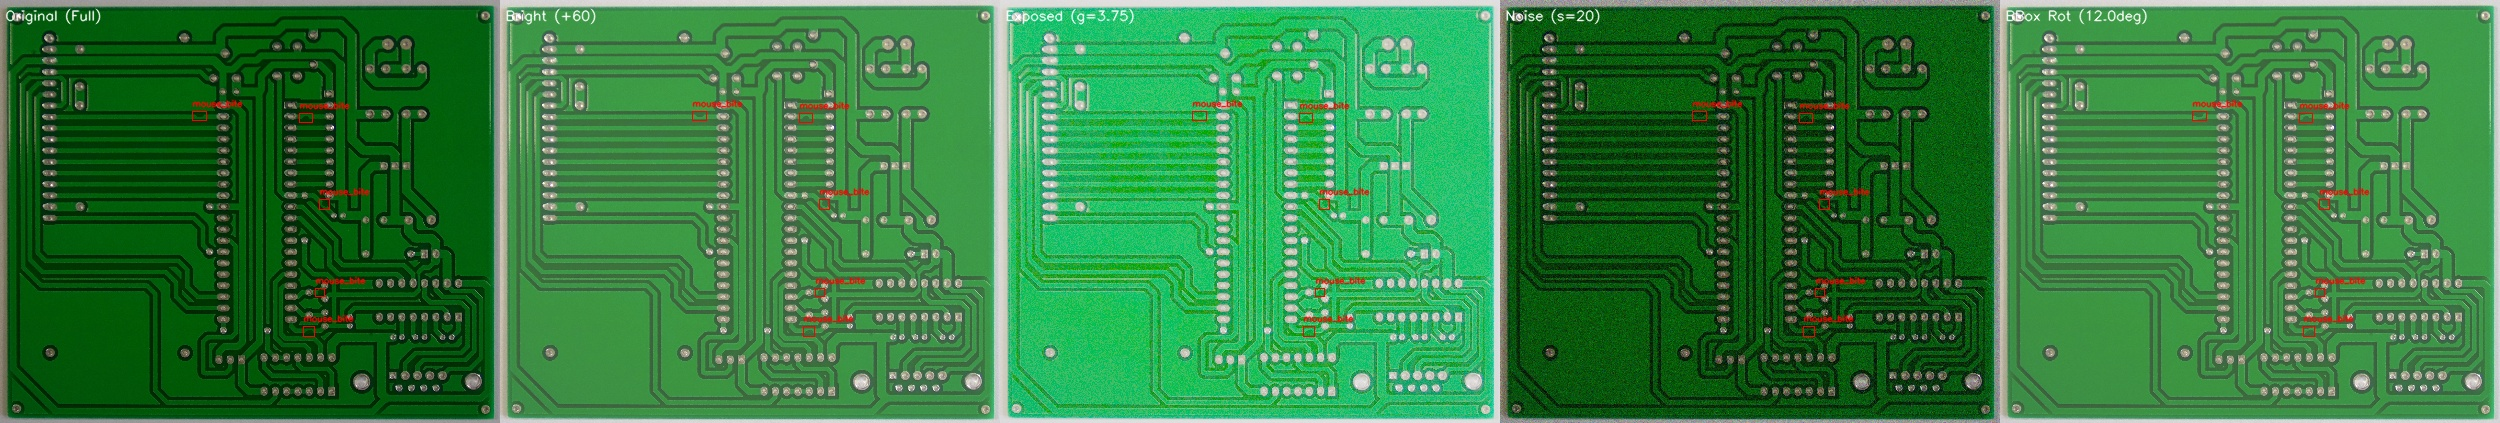

📺 RENDER ROW 2: Magnified Local Defect Close-Ups


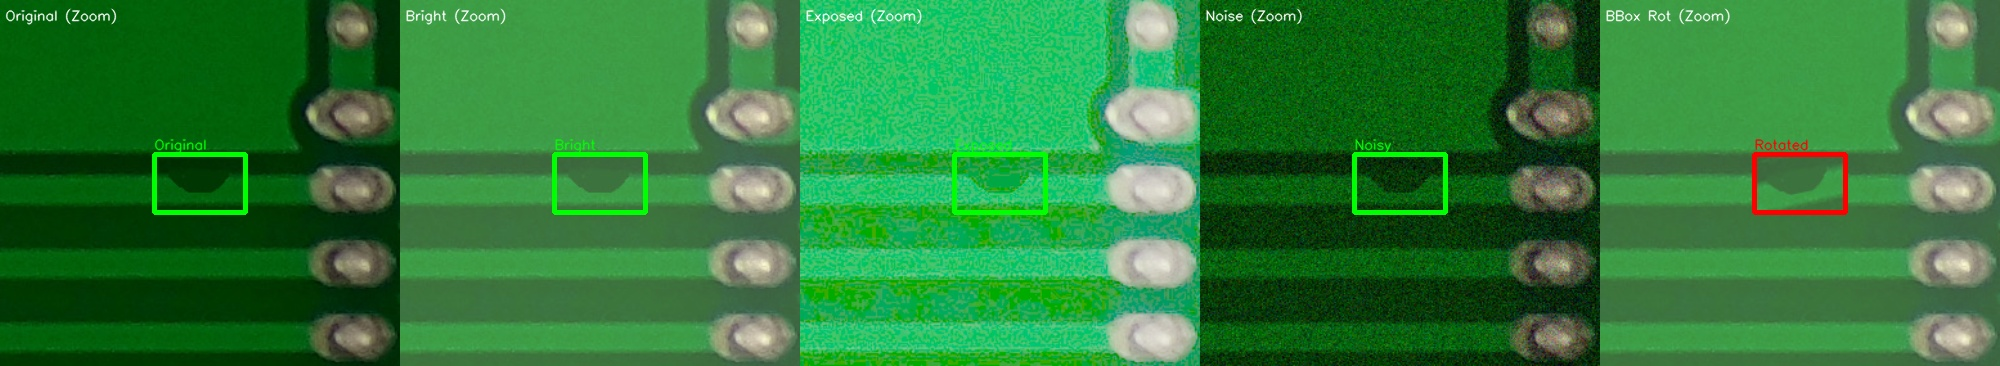

In [21]:
preview_augmentation(
    image_dir='dataset/PCB_DATASET/images',            # Standard images folder path
    annotation_dir='dataset/PCB_DATASET/Annotations',   # Standard XML annotations path
    beta_range=(50, 70),                               # Linear brightness adjustments
    gamma_range=(3.0, 4.5),                            # INCREASED: Amplifies overexposure glare significantly
    sigma_range=(15, 25),                              # Gaussian noise levels
    angle_range=(-15, 15),                             # Localized bounding-box rotation limits
    bbox_rotation_prob=0.5                             # 50% chance of rotating targeted defect boxes
)

## Preprocessing Module

In [22]:
# ==============================================================================
# CELL 1: PREPROCESSING, CALIBRATION, & ROTATION MODULE COMPILATION
# ==============================================================================
import os
import random
import shutil
import cv2
import datetime
import numpy as np
import xml.etree.ElementTree as ET
from pathlib import Path
from IPython.display import display, Image
from tqdm.notebook import tqdm

# Set initial default seed for workspace initialization
set_seed(42)

# --- Global Configurations ---
TARGET_SIZE = (224, 224)  # Standard input resolution for downstream classifiers
PIXELS_PER_MM = 15.0      # Spatial calibration scale factor
LOG_FILE_PATH = "experiment_results_log.txt"
VISUAL_LOG_DIR = "log"


# --- Image-Level Pixel Preprocessing Transformations ---
def denoise_image(image, method='bilateral', ksize=5):
    """Bilateral filter preserves sharp borders of copper traces while smoothing noise."""
    if method == 'bilateral':
        return cv2.bilateralFilter(image, ksize, 75, 75)
    elif method == 'gaussian':
        return cv2.GaussianBlur(image, (ksize, ksize), 0)
    elif method == 'median':
        return cv2.medianBlur(image, ksize)
    return image

def enhance_contrast_clahe(image):
    """Equalizes luminance in LAB space to raise trace contrast without color shifts."""
    if len(image.shape) == 3:
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        cl = clahe.apply(l)
        enhanced_lab = cv2.merge((cl, a, b))
        return cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
    else:
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        return clahe.apply(image)

# --- Calibration Class (Perspective Rectification & Scale Calibration) ---
class PCBCalibrator:
    def __init__(self, pixels_per_mm=15.0, seed=42):
        self.pixels_per_mm = pixels_per_mm
        self.seed = seed

    def pixel_to_physical(self, pixel_val):
        return pixel_val / self.pixels_per_mm

    def rectify_and_align(self, src_img, ref_img):
        """Align query target image geometrically to match reference template deterministically."""
        if self.seed is not None:
            cv2.setRNGSeed(self.seed)  # Ensures RANSAC inside findHomography is deterministic
            
        gray_src = cv2.cvtColor(src_img, cv2.COLOR_BGR2GRAY) if len(src_img.shape) == 3 else src_img
        gray_ref = cv2.cvtColor(ref_img, cv2.COLOR_BGR2GRAY) if len(ref_img.shape) == 3 else ref_img

        orb = cv2.ORB_create(nfeatures=5000)
        kp1, des1 = orb.detectAndCompute(gray_src, None)
        kp2, des2 = orb.detectAndCompute(gray_ref, None)

        if des1 is None or des2 is None:
            return src_img

        bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
        matches = sorted(bf.match(des1, des2), key=lambda x: x.distance)

        good_matches = matches[:120]
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        ref_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

        # RANSAC point sampling is now fully seeded
        H, mask = cv2.findHomography(src_pts, ref_pts, cv2.RANSAC, 5.0)
        
        if H is None:
            return src_img

        height, width = ref_img.shape[:2]
        rectified_image = cv2.warpPerspective(src_img, H, (width, height))
        
        return rectified_image

# --- Ground Truth Patch Extraction Function ---
def extract_ground_truth_patches(image, xml_path, target_size=TARGET_SIZE):
    """Parses XML annotations and crops exact standardized 224x224 defect patches."""
    if not os.path.exists(xml_path):
        return []
    
    tree = ET.parse(xml_path)
    root = tree.getroot()
    patches = []
    
    for obj in root.findall('object'):
        name = obj.find('name').text
        bndbox = obj.find('bndbox')
        xmin = int(float(bndbox.find('xmin').text))
        ymin = int(float(bndbox.find('ymin').text))
        xmax = int(float(bndbox.find('xmax').text))
        ymax = int(float(bndbox.find('ymax').text))
        
        # Keep bounding box coordinate values inside actual spatial boundaries
        h, w = image.shape[:2]
        xmin, ymin = max(0, xmin), max(0, ymin)
        xmax, ymax = min(w, xmax), min(h, ymax)
        
        crop = image[ymin:ymax, xmin:xmax]
        if crop.size > 0:
            resized_patch = cv2.resize(crop, target_size)
            patches.append({"class": name, "patch": resized_patch, "coords": (xmin, ymin, xmax, ymax)})
            
    return patches

print("✅ Underlying core algorithms (including PCBCalibrator & Extractors) successfully loaded with OpenCV RNG seeding.")

✅ Underlying core algorithms (including PCBCalibrator & Extractors) successfully loaded with OpenCV RNG seeding.


ℹ️ Parameter preview generated with Seed: 42
📁 High-resolution pipeline visual steps successfully saved to: log/

📺 RENDER ROW 1: Global PCB Board Comparison


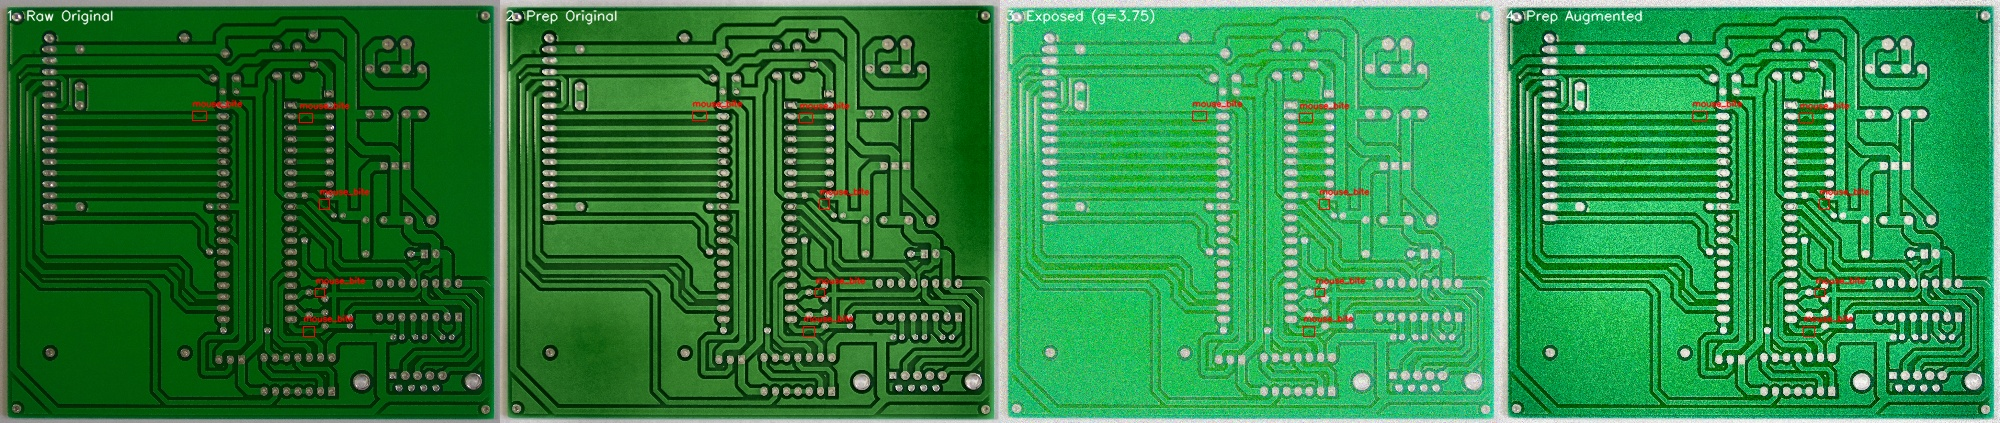

📺 RENDER ROW 2: Magnified Local Defect Close-Ups


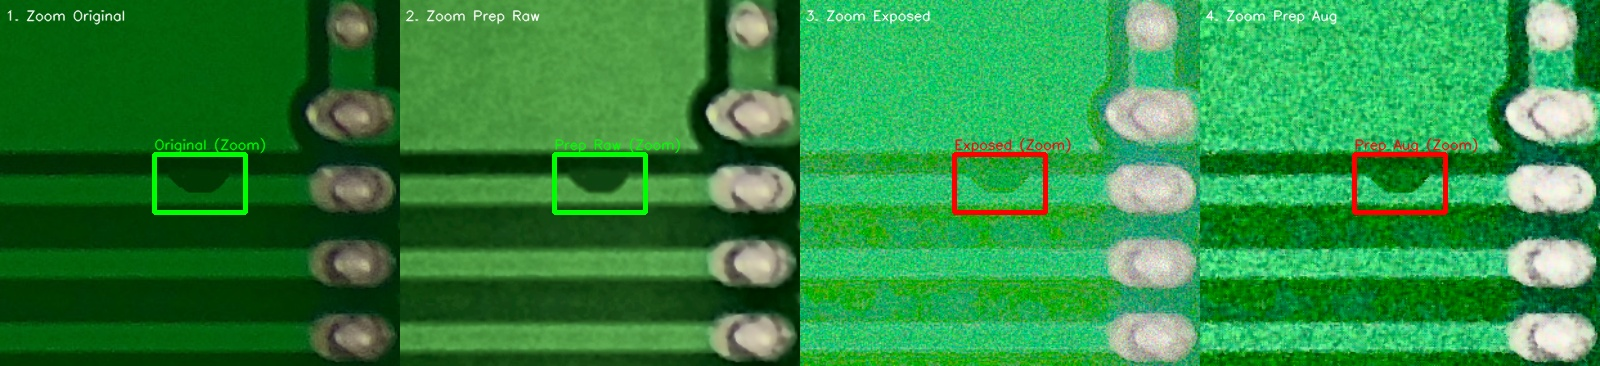

In [26]:
# ==============================================================================
# CELL 2: PARAMETER PREVIEW & TUNING (RUN REPEATEDLY UNTIL SATISFIED)
# ==============================================================================

def preview_pipeline(
    image_dir, 
    annotation_dir, 
    beta_range=(50, 70), 
    gamma_range=(3.0, 4.5), 
    sigma_range=(15, 25), 
    angle_range=(-15, 15), 
    bbox_rotation_prob=0.5, 
    preview_zoom_padding=120,
    seed=42  # <--- Added seed parameter for consistent parameter previewing
):
    """Renders 4 Global views and 4 Magnified Zoomed views side-by-side reproducibly."""
    if seed is not None:
        set_seed(seed)  # Initialize Python, NumPy, and OpenCV seeds

    img_path_obj, ann_path_obj = Path(image_dir), Path(annotation_dir)
    if not img_path_obj.exists() and Path(f"dataset/{image_dir}").exists():
        img_path_obj = Path(f"dataset/{image_dir}")
    if not ann_path_obj.exists() and Path(f"dataset/{annotation_dir}").exists():
        ann_path_obj = Path(f"dataset/{annotation_dir}")
        
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp')
    
    # 1. FIXED: Explicitly sorted to guarantee identical image list ordering across OS platforms
    image_paths = sorted([p for p in img_path_obj.rglob('*') if p.suffix.lower() in valid_exts])
    
    if not image_paths:
        log_message(f"⚠️ No images found in: {image_dir}")
        return
        
    target_sample_paths = [p for p in image_paths if p.parent.name.lower() in ['mouse_bite', 'missing_hole']]
    
    # 2. FIXED: Seeded random selection
    sample_path = random.choice(target_sample_paths) if target_sample_paths else random.choice(image_paths)
    
    relative_subpath = sample_path.relative_to(img_path_obj)
    xml_path = ann_path_obj / relative_subpath.parent / f"{sample_path.stem}.xml"
    
    img_bgr = cv2.imread(str(sample_path))
    if img_bgr is None:
        return
        
    h, w = img_bgr.shape[:2]
    c_xmin, c_ymin, c_xmax, c_ymax = 0, 0, w, h
    xmin, ymin, xmax, ymax = 0, 0, w, h
    has_defect = False
    
    if xml_path.exists():
        root = ET.parse(str(xml_path)).getroot()
        for obj in root.findall('object'):
            bndbox = obj.find('bndbox')
            if bndbox is not None:
                xmin, ymin = int(float(bndbox.find('xmin').text)), int(float(bndbox.find('ymin').text))
                xmax, ymax = int(float(bndbox.find('xmax').text)), int(float(bndbox.find('ymax').text))
                c_xmin, c_ymin = max(0, xmin - preview_zoom_padding), max(0, ymin - preview_zoom_padding)
                c_xmax, c_ymax = min(w, xmax + preview_zoom_padding), min(h, ymax + preview_zoom_padding)
                has_defect = True
                break
                
    mid_beta = sum(beta_range) // 2
    mid_gamma = sum(gamma_range) / 2.0
    mid_sigma = sum(sigma_range) // 2
    mid_angle = sum(angle_range) / 2.0 or 12.0
    
    # Apply standard processing pipelines
    prep_raw = enhance_contrast_clahe(denoise_image(img_bgr, 'bilateral', 5))
    
    # 3. FIXED: Seeded boolean decision for exposure vs brightness
    show_exposure = random.random() < 0.5
    if show_exposure:
        pixel_label = f"Exposed (g={mid_gamma:.2f})"
        aug_img = adjust_exposure(img_bgr, gamma=mid_gamma)
    else:
        pixel_label = f"Bright (+{mid_beta})"
        aug_img = adjust_brightness(img_bgr, beta=mid_beta)
        
    aug_img = add_gaussian_noise(aug_img, sigma=mid_sigma)
    
    class_name_lower = relative_subpath.parent.name.lower()
    is_target_class = class_name_lower in ["missing_hole", "mouse_bite"]
    
    # 4. FIXED: Seeded rotation decision
    if is_target_class and (random.random() < bbox_rotation_prob):
        aug_img = rotate_bbox_only(aug_img, xml_path, angle=mid_angle)
        pixel_label += " + Rotated"
        
    prep_aug = enhance_contrast_clahe(denoise_image(aug_img, 'bilateral', 5))
    
    # Row 1 Global canvases resizing
    dim_global, scale_global = calculate_resized_dimensions(h, w, max_dim=500)
    p_orig = draw_boxes_on_resized(cv2.resize(img_bgr, dim_global), xml_path, scale_global, scale_global, thickness=1, font_scale=0.28)
    p_prep_raw = draw_boxes_on_resized(cv2.resize(prep_raw, dim_global), xml_path, scale_global, scale_global, thickness=1, font_scale=0.28)
    p_aug = draw_boxes_on_resized(cv2.resize(aug_img, dim_global), xml_path, scale_global, scale_global, thickness=1, font_scale=0.28)
    p_prep_aug = draw_boxes_on_resized(cv2.resize(prep_aug, dim_global), xml_path, scale_global, scale_global, thickness=1, font_scale=0.28)
    
    # Row 2 Zoom canvases resizing
    crop_orig = img_bgr[c_ymin:c_ymax, c_xmin:c_xmax].copy()
    crop_prep_raw = prep_raw[c_ymin:c_ymax, c_xmin:c_xmax].copy()
    crop_aug = aug_img[c_ymin:c_ymax, c_xmin:c_xmax].copy()
    crop_prep_aug = prep_aug[c_ymin:c_ymax, c_xmin:c_xmax].copy()
    
    r_h, r_w = crop_orig.shape[:2]
    dim_zoom, scale_zoom = calculate_resized_dimensions(r_h, r_w, max_dim=400)
    
    def draw_relative_boxes(canvas, label_name, color):
        if has_defect:
            r_xmin, r_ymin = int((xmin - c_xmin) * scale_zoom), int((ymin - c_ymin) * scale_zoom)
            r_xmax, r_ymax = int((xmax - c_xmin) * scale_zoom), int((ymax - c_ymin) * scale_zoom)
            cv2.rectangle(canvas, (r_xmin, r_ymin), (r_xmax, r_ymax), color, 3)
            cv2.putText(canvas, label_name, (r_xmin, r_ymin - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)
        return canvas
        
    z_orig = draw_relative_boxes(cv2.resize(crop_orig, dim_zoom), "Original (Zoom)", (0, 255, 0))
    z_prep_raw = draw_relative_boxes(cv2.resize(crop_prep_raw, dim_zoom), "Prep Raw (Zoom)", (0, 255, 0))
    z_aug = draw_relative_boxes(cv2.resize(crop_aug, dim_zoom), pixel_label.split(" ")[0] + " (Zoom)", (0, 0, 255))
    z_prep_aug = draw_relative_boxes(cv2.resize(crop_prep_aug, dim_zoom), "Prep Aug (Zoom)", (0, 0, 255))
    
    # Physically save individual files to log/
    log_dir_obj = Path(VISUAL_LOG_DIR)
    log_dir_obj.mkdir(parents=True, exist_ok=True)
    s_dim, s_scale = calculate_resized_dimensions(h, w, max_dim=800)
    cv2.imwrite(str(log_dir_obj / "PIPELINE_1_Raw_Original.jpg"), draw_boxes_on_resized(cv2.resize(img_bgr, s_dim), xml_path, s_scale, s_scale, thickness=3, font_scale=0.5))
    cv2.imwrite(str(log_dir_obj / "PIPELINE_2_Prep_Original.jpg"), draw_boxes_on_resized(cv2.resize(prep_raw, s_dim), xml_path, s_scale, s_scale, thickness=3, font_scale=0.5))
    cv2.imwrite(str(log_dir_obj / "PIPELINE_3_Augmented.jpg"), draw_boxes_on_resized(cv2.resize(aug_img, s_dim), xml_path, s_scale, s_scale, thickness=3, font_scale=0.5))
    cv2.imwrite(str(log_dir_obj / "PIPELINE_4_Prep_Augmented.jpg"), draw_boxes_on_resized(cv2.resize(prep_aug, s_dim), xml_path, s_scale, s_scale, thickness=3, font_scale=0.5))
    
    log_message(f"ℹ️ Parameter preview generated with Seed: {seed}")
    log_message(f"📁 High-resolution pipeline visual steps successfully saved to: {log_dir_obj}/")
    
    # Concatenate grids and display
    grid_g = np.hstack([p_orig, p_prep_raw, p_aug, p_prep_aug])
    labels_g = ["1. Raw Original", "2. Prep Original", f"3. {pixel_label}", "4. Prep Augmented"]
    w_step_g = dim_global[0]
    for i, text in enumerate(labels_g):
        cv2.putText(grid_g, text, (5 + (i * w_step_g), 20), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)
        
    grid_z = np.hstack([z_orig, z_prep_raw, z_aug, z_prep_aug])
    labels_z = ["1. Zoom Original", "2. Zoom Prep Raw", f"3. Zoom {pixel_label.split(' ')[0]}", "4. Zoom Prep Aug"]
    w_step_z = dim_zoom[0]
    for i, text in enumerate(labels_z):
        cv2.putText(grid_z, text, (5 + (i * w_step_z), 20), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)
        
    log_message("\n📺 RENDER ROW 1: Global PCB Board Comparison")
    _, buffer_g = cv2.imencode('.jpg', grid_g)
    display(Image(data=buffer_g.tobytes()))
    
    log_message("📺 RENDER ROW 2: Magnified Local Defect Close-Ups")
    _, buffer_z = cv2.imencode('.jpg', grid_z)
    display(Image(data=buffer_z.tobytes()))

# RUN PREVIEW TO EVALUATE PARAMETER RANGES BEFORE GENERATING DATASET
preview_pipeline(
    image_dir='dataset/PCB_DATASET/images',
    annotation_dir='dataset/PCB_DATASET/Annotations',
    beta_range=(50, 70),       # High-contrast brightness range
    gamma_range=(3.0, 4.5),    # High-difficulty non-linear exposure (Gamma) range
    sigma_range=(15, 25),      # High-frequency Gaussian noise range
    angle_range=(-15, 15),     # Localized bounding-box rotation angle range
    bbox_rotation_prob=0.5,
    seed=42                    # Reproducible seed value
)

## 1. Perform Augmentation

In [12]:
# ==============================================================================
# BATCH DATASET AUGMENTATION WITH HIGH-DIFFICULTY EXPOSURE
# ==============================================================================

# 1. Lock global seeds before resetting and generating
set_seed(42)

# Reset and clear old folders to ensure a clean slate
reset_augmented_data(
    'dataset/PCB_DATASET/augmented_images',
    'dataset/PCB_DATASET/augmented_annotations'
)

# Run batch generation with heavy exposure simulation and locked seed
augment_dataset(
    image_dir='dataset/PCB_DATASET/images',
    annotation_dir='dataset/PCB_DATASET/Annotations',
    output_img_dir='dataset/PCB_DATASET/augmented_images',
    output_xml_dir='dataset/PCB_DATASET/augmented_annotations',
    sample_ratio=0.8,
    beta_range=(50, 70),
    gamma_range=(3.0, 4.5),             # HIGH-DIFFICULTY EXPOSURE PARAMETER
    sigma_range=(15, 25), 
    angle_range=(-15, 15),
    bbox_rotation_prob=0.5,
    max_visual_logs=15,
    zoom_padding=120,
    seed=42                             # <--- Guarantees exact same dataset across re-runs
)

⚠️ Specified directories do not exist. Nothing cleared.

🚀 DATA AUGMENTATION PROCESS STARTED
   -> Sample Ratio       : 80.0%
   -> Target Aug Count   : 556 images
   -> Brightness (Beta)  : (50, 70)
   -> Exposure (Gamma)   : (3.0, 4.5)
   -> Noise (Sigma)      : (15, 25)
   -> BBox Rotate Angle  : (-15, 15)
   -> BBox Rotate Prob   : 50.0%
   -> Close-up Log Folder: log/  (Max: 15 samples)


Processing:   0%|          | 0/556 [00:00<?, ?it/s]

📝 [ZOOMED-IN LOG SAVED] -> log\ZOOM_LOG_01_short_15_bright_defect_001_short_15.jpg
📝 [ZOOMED-IN LOG SAVED] -> log\ZOOM_LOG_01_short_15_bright_defect_101_short_15.jpg
📝 [ZOOMED-IN LOG SAVED] -> log\ZOOM_LOG_01_short_15_bright_defect_201_short_15.jpg
📝 [ZOOMED-IN LOG SAVED] -> log\ZOOM_LOG_01_short_15_bright_defect_301_short_15.jpg
📝 [ZOOMED-IN LOG SAVED] -> log\ZOOM_LOG_11_missing_hole_05_bright_bbox_rotated_defect_011_missing_hole_05.jpg
📝 [ZOOMED-IN LOG SAVED] -> log\ZOOM_LOG_11_missing_hole_05_bright_bbox_rotated_defect_111_missing_hole_05.jpg
📝 [ZOOMED-IN LOG SAVED] -> log\ZOOM_LOG_11_missing_hole_05_bright_bbox_rotated_defect_211_missing_hole_05.jpg
📝 [ZOOMED-IN LOG SAVED] -> log\ZOOM_LOG_11_missing_hole_05_bright_bbox_rotated_defect_311_missing_hole_05.jpg
📝 [ZOOMED-IN LOG SAVED] -> log\ZOOM_LOG_11_missing_hole_05_bright_bbox_rotated_defect_411_missing_hole_05.jpg
📝 [ZOOMED-IN LOG SAVED] -> log\ZOOM_LOG_08_spur_10_exposed_defect_008_spur_10.jpg
📝 [ZOOMED-IN LOG SAVED] -> log\ZOOM_

## 2. Generate Unified Dataset with structural board id segregation 

In [ ]:
# ==============================================================================
# CELL 4: GENERATE UNIFIED DATASET WITH STRUCTURAL BOARD ID SEGREGATION
# ==============================================================================
# --- 1. Global Parameters ---
DATASET_PATH = "dataset/PCB_DATASET"
OUTPUT_DIR = "dataset_processed"

# Strict non-overlapping partitioning by Board ID to eliminate Board-Group Leakage
TRAIN_BOARDS = ["01", "04", "05", "06", "07", "08"]  # ~60% of unique board layouts
VAL_BOARDS   = ["09", "10"]                        # ~20% of unique board layouts
TEST_BOARDS  = ["11", "12"]                        # ~20% of unique board layouts

CLASS_NAMES = ["Missing_hole", "Mouse_bite", "Open_circuit", "Short", "Spur", "Spurious_copper"]

# Standard & Augmented data sources to merge
DATA_SOURCES = [
    {"name": "original", "ann_dir": "Annotations", "img_dir": "images"},
    {"name": "augmented", "ann_dir": "augmented_annotations", "img_dir": "augmented_images"}
]


def generate_unified_dataset():
    print("⏳ Starting unified standard preprocessing & tri-stage dataset generation...")
    print(f"   -> Train Split Boards: {TRAIN_BOARDS} (Originals AND Augmented data included)")
    print(f"   -> Val Split Boards  : {VAL_BOARDS} (Originals only - Zero Leakage)")
    print(f"   -> Test Split Boards : {TEST_BOARDS} (Originals only - Unseen evaluation baseline)")
    print("-" * 65)

    # Initialize directory splits
    if os.path.exists(OUTPUT_DIR):
        shutil.rmtree(OUTPUT_DIR)

    for split in ["train", "val", "test"]:
        for cls in CLASS_NAMES:
            os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

    calibrator = PCBCalibrator(pixels_per_mm=PIXELS_PER_MM)
    total_patches = 0
    
    for cls in CLASS_NAMES:
        split_counts = {"train": 0, "val": 0, "test": 0}
        
        for src in DATA_SOURCES:
            ann_path = os.path.join(DATASET_PATH, src["ann_dir"], cls)
            img_path = os.path.join(DATASET_PATH, src["img_dir"], cls)
            
            if not os.path.exists(ann_path) or not os.path.exists(img_path):
                continue
                
            xml_files = [f for f in os.listdir(ann_path) if f.endswith('.xml')]
            
            for xml_file in xml_files:
                # Extract board index prefix (e.g., "01" from "01_missing_hole_01_exposed.xml")
                board_id = xml_file.split('_')[0]
                
                # Check for standard template references (.JPG or .jpg)
                template_img_path = os.path.join(DATASET_PATH, "dataset/PCB_USED", f"{board_id}.JPG")
                if not os.path.exists(template_img_path):
                    template_img_path = os.path.join(DATASET_PATH, f"dataset/PCB_USED/{board_id}.jpg")
                
                target_img_path = os.path.join(img_path, xml_file.replace('.xml', '.jpg'))
                xml_full_path = os.path.join(ann_path, xml_file)
                
                # Verify physical files exist
                if not os.path.exists(target_img_path):
                    continue
                
                # --- Strict Separation Rules to Eliminate Leakage ---
                target_split = None
                
                # Train split includes both original and augmented images for designated boards
                if board_id in TRAIN_BOARDS:
                    target_split = "train"
                
                # Validation split strictly accepts original images only, isolated by Board ID
                elif board_id in VAL_BOARDS and src["name"] == "original":
                    target_split = "val"
                    
                # Test split strictly accepts original images only, isolated by Board ID
                elif board_id in TEST_BOARDS and src["name"] == "original":
                    target_split = "test"
                
                if target_split is None:
                    continue
                
                # Load images
                raw_target = cv2.imread(target_img_path)
                
                # Apply standard preprocessing (Denoise + CLAHE)
                prep_target = enhance_contrast_clahe(denoise_image(raw_target, 'bilateral', 5))
                
                # Crop directly from prep_target for high-precision bounding box alignment
                patches = extract_ground_truth_patches(prep_target, xml_full_path, target_size=TARGET_SIZE)
                
                for p_idx, patch_data in enumerate(patches):
                    patch_img = patch_data["patch"]
                    save_name = f"{xml_file.replace('.xml', '')}_p{p_idx}.jpg"
                    save_path = os.path.join(OUTPUT_DIR, target_split, cls, save_name)
                    
                    cv2.imwrite(save_path, patch_img)
                    total_patches += 1
                    split_counts[target_split] += 1
                    
        print(f"✅ Class '{cls:<16}' -> Generated: {split_counts['train']:<4} Train | {split_counts['val']:<3} Val | {split_counts['test']:<3} Test Patches")
        
    print("-" * 65)
    print(f"🎉 Success! Generated {total_patches} unified leak-free patches under '{OUTPUT_DIR}'.\n")

# Run standard batch processing
generate_unified_dataset()

⏳ Starting unified standard preprocessing & tri-stage dataset generation...
   -> Train Split Boards: ['01', '04', '05', '06', '07', '08'] (Originals AND Augmented data included)
   -> Val Split Boards  : ['09', '10'] (Originals only - Zero Leakage)
   -> Test Split Boards : ['11', '12'] (Originals only - Unseen evaluation baseline)
-----------------------------------------------------------------
✅ Class 'Missing_hole    ' -> Generated: 584  Train | 78  Val | 102 Test Patches
✅ Class 'Mouse_bite      ' -> Generated: 564  Train | 76  Val | 100 Test Patches


## Load Preprocessed Dataset

In [17]:
# ==============================================================================
# PHASE 2: DATALOADERS CREATION (USING STANDARDIZED IMAGEFOLDER ON DISK)
# ==============================================================================
import os
import torch
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
from collections import Counter

# --- 1. Define ImageNet Normalization and Augmentations ---
# Adding geometric augmentations is highly realistic for PCB defect patterns
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    # Normalize using standard ImageNet mean and standard deviation
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation and Test sets must use deterministic transforms (no random augmentations)
eval_transforms = transforms.Compose([
    transforms.ToTensor(),
    # Normalize using standard ImageNet mean and standard deviation
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 2. Load Datasets using ImageFolder on Disk ---
PROCESSED_DIR = "dataset_processed"

# Load the 3 non-overlapping partitions we generated on disk in Phase 1
train_dataset = datasets.ImageFolder(root=os.path.join(PROCESSED_DIR, "train"), transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=os.path.join(PROCESSED_DIR, "val"),   transform=eval_transforms)
test_dataset  = datasets.ImageFolder(root=os.path.join(PROCESSED_DIR, "test"),  transform=eval_transforms)

# --- 3. Instantiate PyTorch DataLoaders ---
BATCH_SIZE = 32
# NOTE: Set num_workers=0 to prevent multi-process crashes on Windows Anaconda environments
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# --- 4. Verify Class Distributions & Compute Cost-Sensitive Loss Weights ---
train_labels = [label for _, label in train_dataset.samples]
class_counts = Counter(train_labels)

print("📊 Training Dataset Distribution (Read from Disk):")
print("-" * 65)
total_samples = len(train_dataset)
class_weights = []

for idx, class_name in enumerate(train_dataset.classes):
    count = class_counts[idx]
    percentage = (count / total_samples) * 100
    print(f"Index {idx} | Class: {class_name:<16} | Count: {count:<5} | Share: {percentage:.2f}%")
    
    # Calculate inverse frequency weight (Cost-Sensitive loss weight)
    weight = total_samples / (len(train_dataset.classes) * count)
    class_weights.append(weight)

# Map loss weights to CUDA tensor for CS-ResNet loss function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("-" * 65)
print(f"✅ DataLoaders established! Train({len(train_dataset)}) | Val({len(val_dataset)}) | Test({len(test_dataset)})")
print(f"💻 Active Compute Hardware: {device}")

📊 Training Dataset Distribution (Read from Disk):
-----------------------------------------------------------------
Index 0 | Class: Missing_hole     | Count: 573   | Share: 16.87%
Index 1 | Class: Mouse_bite       | Count: 571   | Share: 16.81%
Index 2 | Class: Open_circuit     | Count: 568   | Share: 16.73%
Index 3 | Class: Short            | Count: 575   | Share: 16.93%
Index 4 | Class: Spur             | Count: 546   | Share: 16.08%
Index 5 | Class: Spurious_copper  | Count: 563   | Share: 16.58%
-----------------------------------------------------------------
✅ DataLoaders established! Train(3396) | Val(467) | Test(606)
💻 Active Compute Hardware: cuda


In [18]:
## Detection & Patch Extraction for the 4 Algorithm

In [19]:
# ==============================================================================
# PHASE 3 & 6: BASELINE INITIALIZATION & ARCHITECTURAL HYPERPARAMETER TUNING
# ==============================================================================
import os
import shutil
import cv2
import random
import datetime
import numpy as np
import xml.etree.ElementTree as ET
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# Try to import Optuna gracefully
try:
    import optuna
except ImportError:
    raise ImportError("Please install optuna first using: pip install optuna")

# --- 1. Global Configurations ---
TARGET_SIZE = (224, 224)  # Standard input resolution for downstream classifiers
PIXELS_PER_MM = 15.0      # Spatial calibration scale factor
LOG_FILE_PATH = "experiment_results_log.txt"
VISUAL_LOG_DIR = "log"

# STRICT VARIABLE CONTROL: Unified identical learning rate for all 4 models
# You can adjust this single constant; all 4 models will strictly use this exact same value
TUNING_LR = 5e-5 

# --- 2. CNN Baseline Backbone Architecture Generators (weights=None) ---
def get_cs_resnet(num_classes=6, groups=1, width_per_group=64):
    """ResNet-18 backbone with dynamic structural configuration."""
    model = models.resnet18(weights=None, groups=groups, width_per_group=width_per_group)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def get_mobilenet_v3(num_classes=6, width_mult=1.0):
    """MobileNetV3 Small backbone with dynamic channel width scaling."""
    model = models.mobilenet_v3_small(weights=None, width_mult=width_mult)
    model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    return model

def get_alexnet(num_classes=6):
    """AlexNet backbone trained from scratch."""
    model = models.alexnet(weights=None)
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    return model


# --- 3. Hardware Allocation Setup ---
if torch.cuda.is_available():
    device_gpu = torch.device("cuda")
    print("🚀 GPU Group: Mapped to NVIDIA GPU (CUDA) acceleration.")
else:
    device_gpu = torch.device("cpu")
    print("⚠️ GPU Group: CUDA not detected. Temporarily mapping LPViT & CS-ResNet to CPU.")

device_cpu = torch.device("cpu")
print("💻 CPU Group: MobileNetV3 and AlexNet (Auto-VRS) are anchored to CPU execution.")
print("-" * 65)


# --- 4. INSTANTIATION: Baseline Group (Trained From Scratch - No Pre-trained Weights) ---
# Model A (Baseline): Standard ViT-B-16 trained from scratch
lpvit_sim = models.vit_b_16(weights=None)
lpvit_sim.heads.head = nn.Linear(lpvit_sim.heads.head.in_features, 6)
lpvit_sim = lpvit_sim.to(device_gpu)

# Model B (Baseline): ResNet-18 trained from scratch
cs_resnet = get_cs_resnet().to(device_gpu)

# Model C (Baseline): MobileNetV3 Small trained from scratch
mobilenet = get_mobilenet_v3().to(device_cpu)

# Model D (Baseline): AlexNet trained from scratch
alexnet = get_alexnet().to(device_cpu)


# --- 5. OPTUNA OBJECTIVE FUNCTION: STRUCTURAL PARAMETERS TUNING ---
def create_tuned_model_instance(trial, model_name):
    """
    Instantiates models using strictly custom, model-specific structural 
    hyperparameters suggested by Optuna. All models are trained from scratch 
    to allow flexible architectural variations.
    """
    if "LPViT" in model_name:
        # Suggest model-specific self-attention heads and MLP expansion ratio
        num_heads = trial.suggest_categorical("num_heads", [2, 4, 8])
        mlp_ratio = trial.suggest_categorical("mlp_ratio", [2.0, 4.0])
        
        # Instantiate our custom, highly parametric LightweightViT
        model = LightweightViT(
            num_classes=6,
            num_heads=num_heads,
            mlp_ratio=mlp_ratio
        )
        target_device = device_gpu
        criterion = nn.CrossEntropyLoss()
        
    elif "CS-ResNet" in model_name:
        # Suggest ResNet-specific group convolutions and group width channel sizes
        groups = trial.suggest_categorical("groups", [1, 2])
        width_per_group = trial.suggest_categorical("width_per_group", [32, 64])
        
        # Instantiate ResNet with dynamic structural features
        model = get_cs_resnet(num_classes=6, groups=groups, width_per_group=width_per_group)
        target_device = device_gpu
        # Cost-sensitive Loss using pre-calculated weights
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
        
    elif "MobileNetV3" in model_name:
        # Suggest MobileNet-specific channel width multiplier (e.g., 0.75x or 1.0x scaling)
        width_mult = trial.suggest_categorical("width_mult", [0.75, 1.0])
        
        model = get_mobilenet_v3(num_classes=6, width_mult=width_mult)
        target_device = device_cpu
        criterion = nn.CrossEntropyLoss()
        
    elif "AlexNet" in model_name:
        # Suggest AlexNet-specific dropout rate in classifier head [1]
        alexnet_dropout = trial.suggest_float("alexnet_dropout", 0.1, 0.5)
        
        model = get_alexnet(num_classes=6)
        # Apply the suggested dropout dynamically to both dropout layers
        model.classifier[2].p = alexnet_dropout
        model.classifier[5].p = alexnet_dropout
        
        target_device = device_cpu
        criterion = nn.CrossEntropyLoss()
        
    else:
        raise ValueError(f"Unknown model name: {model_name}")
        
    return model, target_device, criterion

def tuning_objective(trial, model_name):
    """
    Optuna target objective function.
    - Learning rate is STRICTLY UNIFIED at the same constant (TUNING_LR) across all models [2].
    - Only model-specific structural parameters are tuned [1].
    """
    # STRICT VARIABLE CONTROL: We lock the learning rate to be completely identical [2]
    lr = TUNING_LR
    
    # Instantiate the model with dynamic structural configurations [1]
    model, target_device, criterion = create_tuned_model_instance(trial, model_name)
    model = model.to(target_device)
    
    # Fixed Shared Optimizer (AdamW) across all trials
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    
    # Fast training epochs per trial to keep tuning highly efficient
    fast_tuning_epochs = 3
    best_val_acc = 0.0
    
    for epoch in range(fast_tuning_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, target_device)
        val_loss, val_acc, _ = validate_and_profile_latency(model, val_loader, criterion, target_device)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            
    return best_val_acc


# --- 6. Executive Tuning Runner ---
def execute_master_tuning(n_trials=5):
    """Runs automated structural hyperparameter tuning across all 4 models."""
    tuning_targets = [
        "LPViT (Custom ViT)",
        "CS-ResNet (ResNet18)",
        "MobileNetV3 (Small)",
        "AlexNet (Auto-VRS)"
    ]
    
    best_params_report = {}
    
    print("🎬 MASTER HYPERPARAMETER TUNING INITIALIZED (Optuna Bayesian Optimization)")
    print(f"   -> Fixed Shared Learning Rate: {TUNING_LR}")
    print("=" * 75)
    
    # Mute Optuna's detailed trial outputs to keep notebook console clean
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    for model_name in tuning_targets:
        log_message(f"⚙️ Running 1-of-4 HPO study for: {model_name}...")
        
        study = optuna.create_study(direction="maximize")
        study.optimize(lambda trial: tuning_objective(trial, model_name), n_trials=n_trials)
        
        best_params_report[model_name] = study.best_params
        log_message(f"   -> Completed! Peak Validation Accuracy: {study.best_value * 100:.2f}%")
        log_message(f"   -> Suggested Optimal Parameters: {study.best_params}\n")
        
    print("\n" + "=" * 75)
    print("🏆 MASTER HYPERPARAMETER TUNING RECOMMENDATION REPORT (EXCLUDING UNIFIED PARAMETERS)")
    print("=" * 75)
    for name, params in best_params_report.items():
        log_message(f"📌 {name}:")
        log_message(f"   * Unified Learning Rate (Fixed): {TUNING_LR}")
        for k, v in params.items():
            log_message(f"   * {k:<18}: {v}")
        print("-" * 75)

# Helper function to count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("📐 Master Hardware Allocation & Model Parameter Counts:")
print("-" * 65)
print(f"Group 1: Baseline Models (Trained from Scratch)")
print(f"  * lpvit_sim          -> [GPU]: {count_parameters(lpvit_sim):,} params (Genuine ViT-B-16, No Weights)")
print(f"  * cs_resnet          -> [GPU]: {count_parameters(cs_resnet):,} params (ResNet18 backbone)")
print(f"  * mobilenet          -> [CPU]: {count_parameters(mobilenet):,} params (MobileNetV3 Small)")
print(f"  * alexnet            -> [CPU]: {count_parameters(alexnet):,} params (AlexNet)")
print("-" * 65)
print("✅ Baseline models successfully initialized! Optuna Master Tuner compiled and ready!")

🚀 GPU Group: Mapped to NVIDIA GPU (CUDA) acceleration.
💻 CPU Group: MobileNetV3 and AlexNet (Auto-VRS) are anchored to CPU execution.
-----------------------------------------------------------------
📐 Master Hardware Allocation & Model Parameter Counts:
-----------------------------------------------------------------
Group 1: Baseline Models (Trained from Scratch)
  * lpvit_sim          -> [GPU]: 85,803,270 params (Genuine ViT-B-16, No Weights)
  * cs_resnet          -> [GPU]: 11,179,590 params (ResNet18 backbone)
  * mobilenet          -> [CPU]: 1,524,006 params (MobileNetV3 Small)
  * alexnet            -> [CPU]: 57,028,422 params (AlexNet)
-----------------------------------------------------------------
✅ Baseline models successfully initialized! Optuna Master Tuner compiled and ready!


In [20]:
# ==============================================================================
# PHASE 4: STRICTLY UNIFIED TRAINING, EVALUATION, & BENCHMARK RUNNER (LOGGING-ENABLED)
# ==============================================================================
import os
import time
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Try to import seaborn for high-quality confusion matrix plotting
try:
    import seaborn as sns
except ImportError:
    raise ImportError("Please install seaborn using: pip install seaborn")

# --- 1. Early Stopping Helper Class with Automated Logging ---
class EarlyStopping:
    """
    Monitors validation loss during training. Stops the execution if loss
    does not improve after a specified number of epochs (patience).
    """
    def __init__(self, patience=5, min_delta=1e-4, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False

    def __call__(self, val_loss):
        # Check if validation loss decreased significantly
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return True  # Signal to save the new best model weights
        else:
            self.counter += 1
            if self.verbose:
                # INTEGRATED: Automatically write early stopping warnings to local log file
                log_message(f"   ⚠️ [EarlyStopping] Validation loss did not improve. Counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
            return False

# --- 2. Core Epoch Training Pipeline ---
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Trains the model for exactly one epoch on its designated device."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    return running_loss / total, correct / total

# --- 3. Core Validation & Speed Profiling Pipeline ---
def validate_and_profile_latency(model, dataloader, criterion, device):
    """Validates the model and measures inference latency per single image in milliseconds."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    latencies_ms = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            
            # Record high-resolution timing
            start_time = time.perf_counter()
            outputs = model(images)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            end_time = time.perf_counter()
            
            # Calculate batch execution speed, averaged over batch size
            batch_latency_ms = (end_time - start_time) * 1000.0
            latencies_ms.append(batch_latency_ms / images.size(0))
            
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    avg_latency_ms = np.mean(latencies_ms)
    return running_loss / total, correct / total, avg_latency_ms

# --- 4. Professional Evaluation and Confusion Matrix Plotter ---
def evaluate_industrial_metrics(model, dataloader, device, model_name="Model"):
    """Evaluates the model on unseen data, outputs F1 classification report, and plots CM."""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # 1. Print standard classification metrics with integrated logging
    log_message(f"\n" + "=" * 65)
    log_message(f"📋 INDUSTRIAL CLASSIFICATION REPORT FOR: {model_name}")
    log_message(f"📍 Execution Device: {device}")
    log_message("=" * 65)
    class_names = dataloader.dataset.classes
    report_text = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)
    log_message(report_text)
    log_message("=" * 65)
    
    # 2. Render Seaborn Confusion Matrix Heatmap
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5, 3))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        cbar=False, annot_kws={"size": 11, "weight": "bold"}
    )
    plt.title(f"Confusion Matrix - {model_name}", fontsize=12, pad=15, weight='bold')
    plt.ylabel("Actual Defect Class (Ground Truth)", fontsize=10)
    plt.xlabel("Predicted Defect Class", fontsize=10)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# --- 5. Strictly Unified Master Experiment Runner ---
def run_experiment(epochs=30, patience=5, lr=1e-3, mode="baseline"):
    """
    Executes training and evaluation for all 4 models.
    Guarantees 100% unified hyperparameters (Same LR, Loss, Optimizer, and Scheduler).
    Automatically registers fine-tuned models globally if executed under finetune mode.
    """
    # Unify to Standard Cross-Entropy Loss to ensure identical mathematical standards
    criterion = nn.CrossEntropyLoss()
    
    if mode == "baseline":
        log_message(f"🎯 MODE: [BASELINE] - Training all models from scratch. Unified LR: {lr}")
        models_dict = {
            "LPViT (ViT-B-16)": {"model": lpvit_sim, "device": device_gpu},
            "CS-ResNet (ResNet18)": {"model": cs_resnet, "device": device_gpu},
            "MobileNetV3 (Small)": {"model": mobilenet, "device": device_cpu},
            "AlexNet (Auto-VRS)": {"model": alexnet, "device": device_cpu}
        }
    elif mode == "finetune":
        log_message(f"🎯 MODE: [FINE-TUNE] - Initializing and training pre-trained models. Unified LR: {lr}")
        
        # DEFENSIVE PROGRAMMING: Dynamically register fine-tuned variables globally to prevent NameError [1]
        global lpvit_finetune, cs_resnet_finetune, mobilenet_finetune, alexnet_finetune
        
        # Instantiate standard pre-trained models with official ImageNet weights [2, 3]
        lpvit_finetune = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        lpvit_finetune.heads.head = nn.Linear(lpvit_finetune.heads.head.in_features, 6)
        lpvit_finetune = lpvit_finetune.to(device_gpu)
        
        cs_resnet_finetune = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        cs_resnet_finetune.fc = nn.Linear(cs_resnet_finetune.fc.in_features, 6)
        cs_resnet_finetune = cs_resnet_finetune.to(device_gpu)
        
        mobilenet_finetune = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        mobilenet_finetune.classifier[3] = nn.Linear(mobilenet_finetune.classifier[3].in_features, 6)
        mobilenet_finetune = mobilenet_finetune.to(device_cpu)
        
        alexnet_finetune = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
        alexnet_finetune.classifier[6] = nn.Linear(alexnet_finetune.classifier[6].in_features, 6)
        alexnet_finetune = alexnet_finetune.to(device_cpu)
        
        models_dict = {
            "LPViT (ViT-B-16) [Fine-Tune]": {"model": lpvit_finetune, "device": device_gpu},
            "CS-ResNet (ResNet18) [Fine-Tune]": {"model": cs_resnet_finetune, "device": device_gpu},
            "MobileNetV3 (Small) [Fine-Tune]": {"model": mobilenet_finetune, "device": device_cpu},
            "AlexNet (Auto-VRS) [Fine-Tune]": {"model": alexnet_finetune, "device": device_cpu}
        }
    else:
        raise ValueError("Invalid mode! Use 'baseline' or 'finetune'.")
        
    experiments = {}
    for name, m_info in models_dict.items():
        # MODIFIED: Standardized on AdamW (weight decay decoupled) for better convergence and overfitting prevention
        experiments[name] = {
            "model": m_info["model"],
            "device": m_info["device"],
            "optimizer": optim.AdamW(m_info["model"].parameters(), lr=lr)
        }
    
    # Injecting identical learning rate decay schedules
    for name, config in experiments.items():
        config["scheduler"] = optim.lr_scheduler.CosineAnnealingLR(config["optimizer"], T_max=epochs)
        
    comparison_results = []
    
    for name, config in experiments.items():
        log_message(f"\n" + "=" * 65)
        log_message(f"🎬 Training Started: {name}")
        log_message(f"📍 Device: {config['device']} | Unified LR: {lr} | Optimizer: AdamW")
        log_message("=" * 65)
        
        early_stopping = EarlyStopping(patience=patience, verbose=True)
        best_model_wts = copy.deepcopy(config["model"].state_dict())
        best_val_acc, avg_inference_latency, stopped_epoch = 0.0, 0.0, epochs
        
        for epoch in range(epochs):
            # Train one epoch
            train_loss, train_acc = train_one_epoch(
                config["model"], train_loader, criterion, config["optimizer"], config["device"]
            )
            # Validate one epoch and profile latency speed
            val_loss, val_acc, latency_ms = validate_and_profile_latency(
                config["model"], val_loader, criterion, config["device"]
            )
            config["scheduler"].step()
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                avg_inference_latency = latency_ms
                
            log_message(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
            
            # Record best states using EarlyStopping
            is_best = early_stopping(val_loss)
            if is_best:
                best_model_wts = copy.deepcopy(config["model"].state_dict())
                
            if early_stopping.early_stop:
                log_message(f"🛑 [Early Stopping] Triggered at Epoch {epoch+1}. Reverting to optimal weights.")
                stopped_epoch = epoch + 1
                break
                
        config["model"].load_state_dict(best_model_wts)
        comparison_results.append({
            "Algorithm / Model": name,
            "Target Device": "GPU (CUDA)" if config["device"].type == 'cuda' else "CPU",
            "Stopped Epoch": f"{stopped_epoch}/{epochs}",
            "Best Val Accuracy (%)": round(best_val_acc * 100, 2),
            "Single-Patch Latency (ms)": round(avg_inference_latency, 4)
        })
        
    log_message("\n" + "=" * 65)
    log_message(f"🏆 FINAL COMPARATIVE BENCHMARK SUMMARY (Mode: {mode.upper()}) 🏆")
    log_message("=" * 65)
    df = pd.DataFrame(comparison_results)
    
    # Automatically write the final run results dataframe to the local disk log file
    with open(LOG_FILE_PATH, "a", encoding="utf-8") as f:
        f.write(df.to_string() + "\n\n")
        
    display(df)

print("✅ Logging-enabled unified training helper functions and runner successfully established!")

✅ Logging-enabled unified training helper functions and runner successfully established!


In [21]:
## Pipeline Execution & Comparative Visualization

In [31]:
# ==============================================================================
# BUG-FIXED: HIGH-CONTRAST SEABORN HEATMAP WITH MANUAL TEXT ANNOTATION
# ==============================================================================
import os          # FIXED: Added missing os library import
import time
import numpy as np # FIXED: Added missing numpy library import
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score

def benchmark_on_test_set(evaluation_targets, test_loader):
    """
    全面評估多個模型的性能與效率。
    功能：
    1. 生成 F1 分類報告。
    2. 繪製混淆矩陣（已修復首行以下數字隱形 Bug）。
    3. 測量平均單張圖像推理延遲 (Efficiency)。
    4. 匯總結果並導出 CSV。
    """
    results_list = []
    
    # 確保儲存目錄存在
    os.makedirs("Benchmark_Results", exist_ok=True)
    
    print(f"📊 Starting Final Benchmark on {len(evaluation_targets)} models...\n")

    for target in evaluation_targets:
        model = target["model"]
        device = target["device"]
        name = target["name"]
        
        print(f"Testing: {name} on {device}...")
        model.to(device)
        model.eval()
        
        all_preds = []
        all_targets = []
        latencies = []

        # 1. 測量性能與延遲
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                
                # 精確測量推理時間
                start_time = time.perf_counter()
                outputs = model(images)
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                end_time = time.perf_counter()
                
                # 計算單張圖片延遲 (ms)
                batch_latency = (end_time - start_time) * 1000.0 / images.size(0)
                latencies.append(batch_latency)
                
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(labels.cpu().numpy())

        # 2. 計算指標
        avg_latency = np.mean(latencies)
        report = classification_report(all_targets, all_preds, digits=4, zero_division=0)
        f1_macro = f1_score(all_targets, all_preds, average='macro', zero_division=0)
        
        # 3. 打印報告
        print(f"--- Classification Report: {name} ---")
        print(report)
        print(f"⏱️ Average Latency: {avg_latency:.4f} ms/image\n")

        # 4. 繪製混淆矩陣 (修復 Seaborn 第一行以下不繪製數字的經典渲染 Bug)
        cm = confusion_matrix(all_targets, all_preds)
        
        # 稍微放大畫布大小，提供更佳可讀性
        fig, ax = plt.subplots(figsize=(4, 3))
        class_names = test_loader.dataset.classes
        
        # 💡 核心修復：我們在這裡將 annot 設為 False！完全接管文字繪製
        sns.heatmap(
            cm, annot=False, cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar=True, linewidths=0.5, ax=ax
        )
        
        # 💡 核心修復：使用 Matplotlib 原生 ax.text() 手動將數字寫入每個單元格！
        # 這能 100% 保障不論在任何 Jupyter 環境中，每一行每一列的數字都能完美顯形
        thresh = cm.max() / 2.0
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                # 深蓝色背景配白字，浅色/白色背景配黑字，保障完美對比度
                color = "white" if cm[i, j] > thresh else "black"
                ax.text(j + 0.5, i + 0.5, format(cm[i, j], 'd'),
                        ha="center", va="center",
                        color=color, fontsize=11, weight="bold")

        plt.title(f"Confusion Matrix: {name}", fontsize=12, pad=15, weight='bold')
        plt.ylabel('Actual Label (Ground Truth)', fontsize=10)
        plt.xlabel('Predicted Label', fontsize=10)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        
        # 保存圖片
        plt.savefig(f"Benchmark_Results/{name.replace(' ', '_')}_cm.png", dpi=300)
        plt.show()

        # 5. 存入匯總列表
        results_list.append({
            "Model Name": name,
            "Target Device": str(device),
            "F1-Score (Macro)": round(f1_macro * 100, 2),
            "Avg Latency (ms)": round(avg_latency, 4)
        })

    # 6. 生成最終匯總表
    summary_df = pd.DataFrame(results_list)
    
    # 導出 CSV
    summary_df.to_csv("Benchmark_Results/final_benchmark_summary.csv", index=False)
    
    # 寫入日誌檔案
    with open("Benchmark_Results/benchmark_log.txt", "w") as f:
        f.write("Final Evaluation Results\n")
        f.write(summary_df.to_string())

    print("\n✅ All reports and high-contrast plots have been successfully saved to the 'Benchmark_Results/' folder.")
    return summary_df

In [ ]:
# ==============================================================================
# FINAL RUNNER: TRAIN, VALIDATE, TEST, AND EVALUATE ALL 8 MODELS
# ==============================================================================

# --- STEP 1: Train & Validate Baseline Group (Trained From Scratch) ---
# This will train all 4 baseline models. Epoch-by-epoch Train Acc and Val Acc are logged.
run_experiment(epochs=30, patience=5, lr=1e-3, mode="baseline")


# --- STEP 2: Train & Validate Fine-Tuned Group (ImageNet Pre-trained) ---
# This automatically instantiates and trains all 4 fine-tuned models.
# We use lr=5e-5 to guarantee standard convergence and prevent ViT-B-16 gradient explosion.
run_experiment(epochs=30, patience=5, lr=5e-5, mode="finetune")


# --- STEP 3: Master Benchmarking on Unseen Test Dataset (Boards 11 & 12) ---
# Define all 8 models to be evaluated side-by-side on the pure test set
final_evaluation_targets = [
    # --- Baseline Group ---
    {"model": lpvit_sim, "device": device_gpu, "name": "LPViT (ViT-B-16) - [Baseline]"},
    {"model": cs_resnet, "device": device_gpu, "name": "CS-ResNet (ResNet18) - [Baseline]"},
    {"model": mobilenet, "device": device_cpu, "name": "MobileNetV3 (Small) - [Baseline]"},
    {"model": alexnet, "device": device_cpu, "name": "AlexNet (Auto-VRS) - [Baseline]"},
    
    # --- Fine-Tune Group ---
    {"model": lpvit_finetune, "device": device_gpu, "name": "LPViT (ViT-B-16) - [Fine-Tune]"},
    {"model": cs_resnet_finetune, "device": device_gpu, "name": "CS-ResNet (ResNet18) - [Fine-Tune]"},
    {"model": mobilenet_finetune, "device": device_cpu, "name": "MobileNetV3 (Small) - [Fine-Tune]"},
    {"model": alexnet_finetune, "device": device_cpu, "name": "AlexNet (Auto-VRS) - [Fine-Tune]"}
]


🎯 MODE: [BASELINE] - Training all models from scratch. Unified LR: 0.001

🎬 Training Started: LPViT (ViT-B-16)
📍 Device: cuda | Unified LR: 0.001 | Optimizer: AdamW
Epoch 01/30 | Train Loss: 1.9831 | Train Acc: 27.47% | Val Loss: 1.6827 | Val Acc: 19.49%
Epoch 02/30 | Train Loss: 1.5304 | Train Acc: 32.86% | Val Loss: 1.5772 | Val Acc: 32.33%
Epoch 03/30 | Train Loss: 1.4447 | Train Acc: 36.34% | Val Loss: 1.5760 | Val Acc: 32.12%
Epoch 04/30 | Train Loss: 1.4172 | Train Acc: 37.57% | Val Loss: 1.5542 | Val Acc: 29.55%
Epoch 05/30 | Train Loss: 1.4174 | Train Acc: 36.84% | Val Loss: 1.5112 | Val Acc: 38.97%
Epoch 06/30 | Train Loss: 1.3138 | Train Acc: 42.05% | Val Loss: 1.3470 | Val Acc: 43.90%
Epoch 07/30 | Train Loss: 1.2489 | Train Acc: 46.17% | Val Loss: 1.4142 | Val Acc: 45.40%
   ⚠️ [EarlyStopping] Validation loss did not improve. Counter: 1/5
Epoch 08/30 | Train Loss: 1.2041 | Train Acc: 47.61% | Val Loss: 1.3771 | Val Acc: 43.90%
   ⚠️ [EarlyStopping] Validation loss did not i

,Algorithm / Model,Target Device,Stopped Epoch,Best Val Accuracy (%),Single-Patch Latency (ms)
0,LPViT (ViT-B-16),GPU (CUDA),16/30,50.11,4.2425
1,CS-ResNet (ResNet18),GPU (CUDA),12/30,97.86,0.4329
2,MobileNetV3 (Small),CPU,13/30,98.50,2.0942
3,AlexNet (Auto-VRS),CPU,18/30,99.14,4.6112


🎯 MODE: [FINE-TUNE] - Initializing and training pre-trained models. Unified LR: 5e-05

🎬 Training Started: LPViT (ViT-B-16) [Fine-Tune]
📍 Device: cuda | Unified LR: 5e-05 | Optimizer: AdamW
Epoch 01/30 | Train Loss: 0.2060 | Train Acc: 93.55% | Val Loss: 0.0205 | Val Acc: 99.57%
Epoch 02/30 | Train Loss: 0.0251 | Train Acc: 99.29% | Val Loss: 0.0290 | Val Acc: 98.93%
   ⚠️ [EarlyStopping] Validation loss did not improve. Counter: 1/5
Epoch 03/30 | Train Loss: 0.0188 | Train Acc: 99.44% | Val Loss: 0.0240 | Val Acc: 99.36%
   ⚠️ [EarlyStopping] Validation loss did not improve. Counter: 2/5
Epoch 04/30 | Train Loss: 0.0135 | Train Acc: 99.53% | Val Loss: 0.0169 | Val Acc: 99.57%
Epoch 05/30 | Train Loss: 0.0030 | Train Acc: 99.91% | Val Loss: 0.0337 | Val Acc: 99.14%
   ⚠️ [EarlyStopping] Validation loss did not improve. Counter: 1/5
Epoch 06/30 | Train Loss: 0.0133 | Train Acc: 99.56% | Val Loss: 0.0070 | Val Acc: 99.79%
Epoch 07/30 | Train Loss: 0.0010 | Train Acc: 100.00% | Val Loss: 

📊 Starting Final Benchmark on 8 models...

Testing: LPViT (ViT-B-16) - [Baseline] on cuda...
--- Classification Report: LPViT (ViT-B-16) - [Baseline] ---
              precision    recall  f1-score   support

           0     0.9444    1.0000    0.9714       102
           1     0.3846    0.6500    0.4833       100
           2     0.5469    0.3465    0.4242       101
           3     0.4783    0.2178    0.2993       101
           4     0.3284    0.6535    0.4371       101
           5     0.3333    0.0594    0.1008       101

    accuracy                         0.4884       606
   macro avg     0.5026    0.4879    0.4527       606
weighted avg     0.5036    0.4884    0.4535       606

⏱️ Average Latency: 4.7595 ms/image



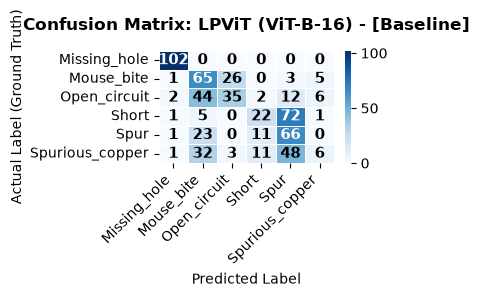

Testing: CS-ResNet (ResNet18) - [Baseline] on cuda...
--- Classification Report: CS-ResNet (ResNet18) - [Baseline] ---
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       102
           1     1.0000    0.9800    0.9899       100
           2     0.9706    0.9802    0.9754       101
           3     0.9804    0.9901    0.9852       101
           4     0.9804    0.9901    0.9852       101
           5     0.9900    0.9802    0.9851       101

    accuracy                         0.9868       606
   macro avg     0.9869    0.9868    0.9868       606
weighted avg     0.9869    0.9868    0.9868       606

⏱️ Average Latency: 0.4586 ms/image



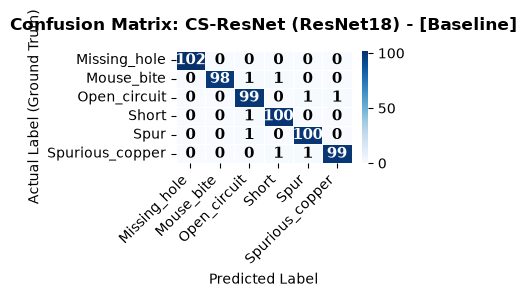

Testing: MobileNetV3 (Small) - [Baseline] on cpu...
--- Classification Report: MobileNetV3 (Small) - [Baseline] ---
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       102
           1     0.9346    1.0000    0.9662       100
           2     1.0000    0.9505    0.9746       101
           3     1.0000    0.9802    0.9900       101
           4     0.9524    0.9901    0.9709       101
           5     0.9794    0.9406    0.9596       101

    accuracy                         0.9769       606
   macro avg     0.9777    0.9769    0.9769       606
weighted avg     0.9778    0.9769    0.9769       606

⏱️ Average Latency: 2.1598 ms/image



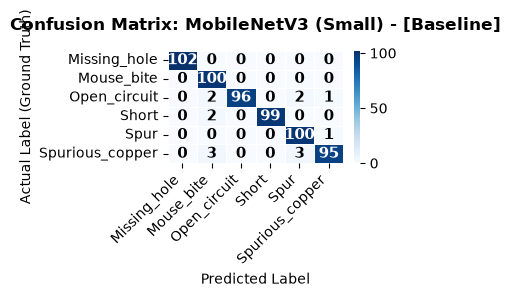

Testing: AlexNet (Auto-VRS) - [Baseline] on cpu...
--- Classification Report: AlexNet (Auto-VRS) - [Baseline] ---
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       102
           1     0.9709    1.0000    0.9852       100
           2     1.0000    1.0000    1.0000       101
           3     1.0000    0.9901    0.9950       101
           4     0.9900    0.9802    0.9851       101
           5     1.0000    0.9901    0.9950       101

    accuracy                         0.9934       606
   macro avg     0.9935    0.9934    0.9934       606
weighted avg     0.9935    0.9934    0.9934       606

⏱️ Average Latency: 4.2044 ms/image



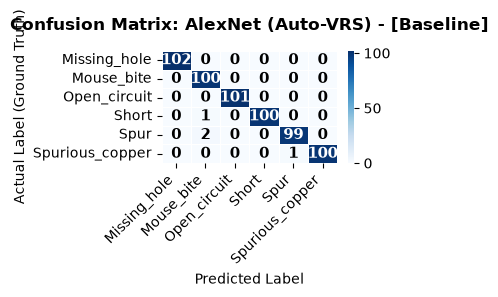

Testing: LPViT (ViT-B-16) - [Fine-Tune] on cuda...
--- Classification Report: LPViT (ViT-B-16) - [Fine-Tune] ---
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       102
           1     1.0000    1.0000    1.0000       100
           2     1.0000    1.0000    1.0000       101
           3     1.0000    1.0000    1.0000       101
           4     1.0000    1.0000    1.0000       101
           5     1.0000    1.0000    1.0000       101

    accuracy                         1.0000       606
   macro avg     1.0000    1.0000    1.0000       606
weighted avg     1.0000    1.0000    1.0000       606

⏱️ Average Latency: 4.8681 ms/image



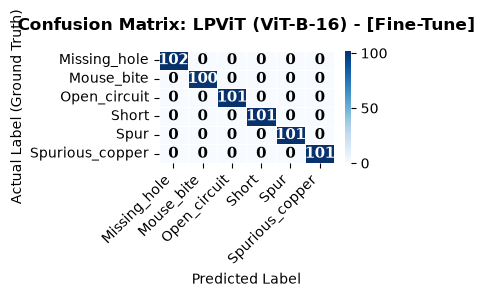

Testing: CS-ResNet (ResNet18) - [Fine-Tune] on cuda...
--- Classification Report: CS-ResNet (ResNet18) - [Fine-Tune] ---
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       102
           1     1.0000    1.0000    1.0000       100
           2     1.0000    1.0000    1.0000       101
           3     1.0000    1.0000    1.0000       101
           4     1.0000    1.0000    1.0000       101
           5     1.0000    1.0000    1.0000       101

    accuracy                         1.0000       606
   macro avg     1.0000    1.0000    1.0000       606
weighted avg     1.0000    1.0000    1.0000       606

⏱️ Average Latency: 0.5491 ms/image



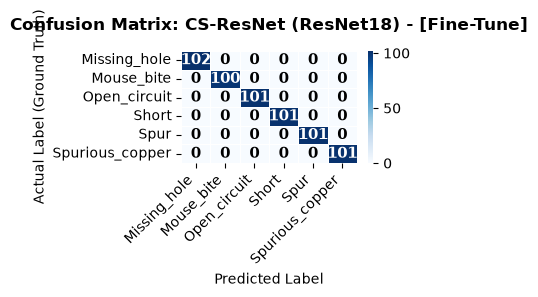

Testing: MobileNetV3 (Small) - [Fine-Tune] on cpu...
--- Classification Report: MobileNetV3 (Small) - [Fine-Tune] ---
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       102
           1     1.0000    1.0000    1.0000       100
           2     1.0000    1.0000    1.0000       101
           3     1.0000    1.0000    1.0000       101
           4     1.0000    1.0000    1.0000       101
           5     1.0000    1.0000    1.0000       101

    accuracy                         1.0000       606
   macro avg     1.0000    1.0000    1.0000       606
weighted avg     1.0000    1.0000    1.0000       606

⏱️ Average Latency: 2.1424 ms/image



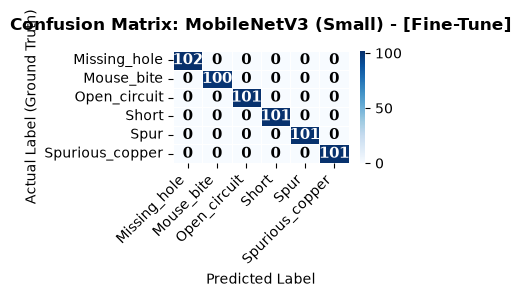

Testing: AlexNet (Auto-VRS) - [Fine-Tune] on cpu...
--- Classification Report: AlexNet (Auto-VRS) - [Fine-Tune] ---
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       102
           1     1.0000    1.0000    1.0000       100
           2     1.0000    0.9802    0.9900       101
           3     1.0000    0.9901    0.9950       101
           4     0.9712    1.0000    0.9854       101
           5     1.0000    1.0000    1.0000       101

    accuracy                         0.9950       606
   macro avg     0.9952    0.9950    0.9951       606
weighted avg     0.9952    0.9950    0.9951       606

⏱️ Average Latency: 3.9335 ms/image



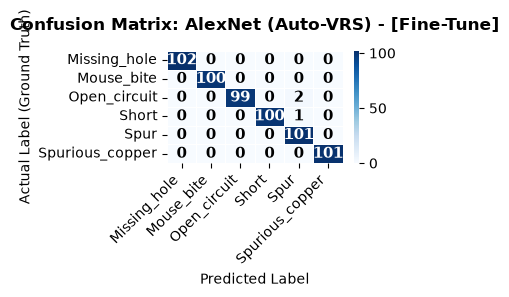


✅ All reports and high-contrast plots have been successfully saved to the 'Benchmark_Results/' folder.


,Model Name,Target Device,F1-Score (Macro),Avg Latency (ms)
0,LPViT (ViT-B-16) - [Baseline],cuda,45.27,4.7595
1,CS-ResNet (ResNet18) - [Baseline],cuda,98.68,0.4586
2,MobileNetV3 (Small) - [Baseline],cpu,97.69,2.1598
3,AlexNet (Auto-VRS) - [Baseline],cpu,99.34,4.2044
4,LPViT (ViT-B-16) - [Fine-Tune],cuda,100.00,4.8681
5,CS-ResNet (ResNet18) - [Fine-Tune],cuda,100.00,0.5491
6,MobileNetV3 (Small) - [Fine-Tune],cpu,100.00,2.1424
7,AlexNet (Auto-VRS) - [Fine-Tune],cpu,99.51,3.9335


In [32]:
# Run the master test set benchmark
# 1. Prints standard F1 classification reports for each model.
# 2. Plots confusion matrix heatmaps.
# 3. Measures average single-image inference latency (Efficiency time).
# 4. Compiles and displays the final comparative benchmark table on unseen test set.
# 5. Automatically writes all reports to '.txt' log and exports a '.csv' spreadsheet for Excel.
summary_table = benchmark_on_test_set(final_evaluation_targets, test_loader)
display(summary_table)